In [ ]:
# =====================================================================
# USER CONFIGURATION: DATASET INITIALIZATION
# NOTE: If running this notebook yourself, download the ec012ec.187 and
# ec012ec.188 datasets from CRCNS.org and update the paths below to
# match your local directory or Google Drive environment.
# =====================================================================

In [ ]:
# load awake data

# 1. Create a clean working folder inside Colab
!mkdir /content/workspace
%cd /content/workspace

# 2. Extract the metadata from your Drive
!unzip /content/drive/MyDrive/hc3_data/crcns-hc3-metadata-tables.zip -d ./metadata

# 3. Unpack the neural data from your Drive
!tar -xvzf /content/drive/MyDrive/hc3_data/ec012ec.187.tar.gz

mkdir: cannot create directory ‘/content/workspace’: File exists
/content/workspace
Archive:  /content/drive/MyDrive/hc3_data/crcns-hc3-metadata-tables.zip
   creating: ./metadata/hc3-metadata-tables/
  inflating: ./metadata/hc3-metadata-tables/hc3-cell.csv  
  inflating: ./metadata/hc3-metadata-tables/hc3-epos.csv  
  inflating: ./metadata/hc3-metadata-tables/hc3-files.csv  
  inflating: ./metadata/hc3-metadata-tables/hc3-session.csv  
  inflating: ./metadata/hc3-metadata-tables/hc3-tables.db  
  inflating: ./metadata/hc3-metadata-tables/hc3-tables.sql  
  inflating: ./metadata/hc3-metadata-tables/hc3-tables.xlsx  
   creating: ./metadata/__MACOSX/
   creating: ./metadata/__MACOSX/hc3-metadata-tables/
  inflating: ./metadata/__MACOSX/hc3-metadata-tables/._hc3-tables.xlsx  
ec012ec.11/ec012ec.187/ec012ec.187.clu.1
ec012ec.11/ec012ec.187/ec012ec.187.clu.2
ec012ec.11/ec012ec.187/ec012ec.187.clu.3
ec012ec.11/ec012ec.187/ec012ec.187.clu.4
ec012ec.11/ec012ec.187/ec012ec.187.eeg
ec012ec.11/e

In [ ]:
# raw data visualize

import glob

# 1. Find the first awake .res and .clu file
res_file = sorted(glob.glob('**/*.187.res.*', recursive=True))[0]
clu_file = res_file.replace('.res.', '.clu.')

print(f"--- RAW DATA SAMPLE ---")
print(f"Reading from: {res_file}")
print("-" * 35)

# 2. Open both files and read the first 10 lines side-by-side
with open(res_file, 'r') as f_res, open(clu_file, 'r') as f_clu:
    print(f"{'Timestamp (Ticks)':<20} | {'Neuron Cluster ID'}")
    print("-" * 35)

    # Skip the first line of the .clu file (it just lists the total number of clusters)
    next(f_clu)

    # Print the first 10 electrical spikes
    for _ in range(10):
        res_val = next(f_res).strip()
        clu_val = next(f_clu).strip()
        print(f"{res_val:<20} | {clu_val}")

--- RAW DATA SAMPLE ---
Reading from: ec012ec.11/ec012ec.187/ec012ec.187.res.1
-----------------------------------
Timestamp (Ticks)    | Neuron Cluster ID
-----------------------------------
136                  | 8
365                  | 6
672                  | 8
1020                 | 8
1105                 | 8
1528                 | 8
2087                 | 8
2368                 | 6
2426                 | 5
3076                 | 8


In [ ]:
import glob

# 1. Find the awake tracking data (.whl file)
whl_files = sorted(glob.glob('**/*.187.whl', recursive=True))

if len(whl_files) > 0:
    whl_file = whl_files[0]
    print(f"--- RAW CAMERA TRACKING DATA SAMPLE ---")
    print(f"Reading from: {whl_file}")
    print("-" * 55)

    # 2. Open the file and read the first 10 lines
    with open(whl_file, 'r') as f_whl:
        print(f"{'LED 1 X':<10} | {'LED 1 Y':<10} | {'LED 2 X':<10} | {'LED 2 Y':<10}")
        print("-" * 55)

        for _ in range(10):
            # The .whl file contains X1, Y1, X2, Y2 separated by spaces
            line = next(f_whl).strip().split()
            # Handle potential empty lines or missing data gracefully
            if len(line) >= 4:
                print(f"{line[0]:<10} | {line[1]:<10} | {line[2]:<10} | {line[3]:<10}")
            else:
                print(line)
else:
    print("Tracking .whl file not found in the current directory structure.")

--- RAW CAMERA TRACKING DATA SAMPLE ---
Reading from: ec012ec.11/ec012ec.187/ec012ec.187.whl
-------------------------------------------------------
LED 1 X    | LED 1 Y    | LED 2 X    | LED 2 Y   
-------------------------------------------------------
-1         | -1         | -1         | -1        
-1         | -1         | -1         | -1        
-1         | -1         | -1         | -1        
-1         | -1         | -1         | -1        
-1         | -1         | -1         | -1        
-1         | -1         | -1         | -1        
-1         | -1         | -1         | -1        
-1         | -1         | -1         | -1        
-1         | -1         | -1         | -1        
-1         | -1         | -1         | -1        


In [ ]:
import glob

# 1. Find the awake tracking data (.whl file)
whl_files = sorted(glob.glob('**/*.187.whl', recursive=True))

if len(whl_files) > 0:
    whl_file = whl_files[0]
    print(f"--- RAW CAMERA TRACKING DATA SAMPLE (Valid Points Only) ---")
    print(f"Reading from: {whl_file}")
    print("-" * 55)

    # 2. Open the file and find the first 10 valid lines
    with open(whl_file, 'r') as f_whl:
        print(f"{'LED 1 X':<10} | {'LED 1 Y':<10} | {'LED 2 X':<10} | {'LED 2 Y':<10}")
        print("-" * 55)

        valid_count = 0
        for line in f_whl:
            data = line.strip().split()

            # Check if there's data AND it's not the -1 placeholder
            if len(data) >= 4 and float(data[0]) != -1:
                print(f"{data[0]:<10} | {data[1]:<10} | {data[2]:<10} | {data[3]:<10}")
                valid_count += 1

            # Stop after we find 10 good tracking points
            if valid_count >= 10:
                break
else:
    print("Tracking .whl file not found in the current directory structure.")

--- RAW CAMERA TRACKING DATA SAMPLE (Valid Points Only) ---
Reading from: ec012ec.11/ec012ec.187/ec012ec.187.whl
-------------------------------------------------------
LED 1 X    | LED 1 Y    | LED 2 X    | LED 2 Y   
-------------------------------------------------------
6.276499e+02 | 2.629169e+02 | 5.814333e+02 | 2.592166e+02
6.299606e+02 | 2.590657e+02 | 5.829737e+02 | 2.599869e+02
6.307571e+02 | 2.552146e+02 | 5.852712e+02 | 2.615142e+02
6.315273e+02 | 2.513635e+02 | 5.875819e+02 | 2.625273e+02
632        | 2.475124e+02 | 5.892975e+02 | 2.627025e+02
6.319322e+02 | 2.437290e+02 | 5.900678e+02 | 2.619322e+02
6.311620e+02 | 2.406481e+02 | 5.908380e+02 | 2.611620e+02
6.303918e+02 | 2.381754e+02 | 5.916082e+02 | 2.603918e+02
6.292431e+02 | 2.354863e+02 | 5.927569e+02 | 260       
628        | 2.324054e+02 | 5.945946e+02 | 2.598513e+02


Loading tracking data from: ec012ec.11/ec012ec.187/ec012ec.187.whl


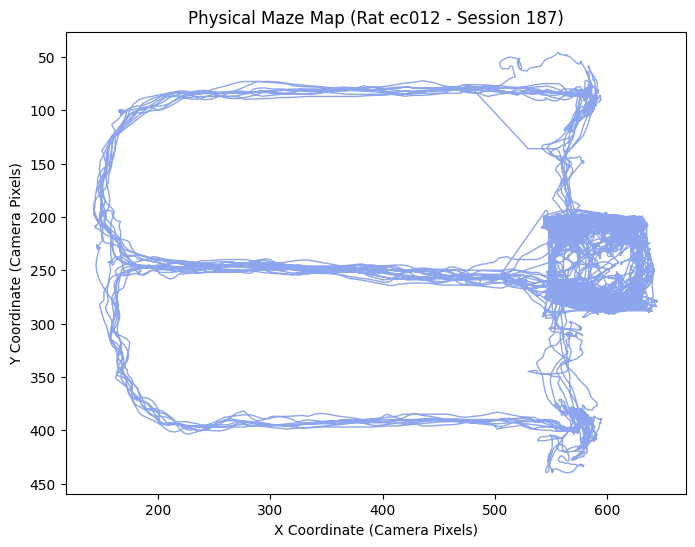

In [ ]:
# whole maze map

import numpy as np
import matplotlib.pyplot as plt
import glob

# 1. Automatically find the .whl file in your workspace
# (Using glob saves us from guessing the exact folder name)
whl_file = glob.glob('**/*.187.whl', recursive=True)[0]
print(f"Loading tracking data from: {whl_file}")

# 2. Load the data
# The file is a giant text matrix of numbers.
# -1 indicates the camera briefly lost the LED.
whl_data = np.loadtxt(whl_file)

# The first two columns are the X and Y coordinates
x = whl_data[:, 0]
y = whl_data[:, 1]

# 3. Clean the data (Filter out the -1 tracking errors)
valid_data = (x != -1) & (y != -1)
x_clean = x[valid_data]
y_clean = y[valid_data]

# 4. Draw the Maze
plt.figure(figsize=(8, 6))
plt.plot(x_clean, y_clean, color='royalblue', alpha=0.6, linewidth=1)
plt.title("Physical Maze Map (Rat ec012 - Session 187)")
plt.xlabel("X Coordinate (Camera Pixels)")
plt.ylabel("Y Coordinate (Camera Pixels)")

# Invert Y axis because image/camera coordinates usually start from the top left
plt.gca().invert_yaxis()
plt.show()

Extracting memory data from Electrode Shank #4...
Neuron #2 fired a total of 1179 times.


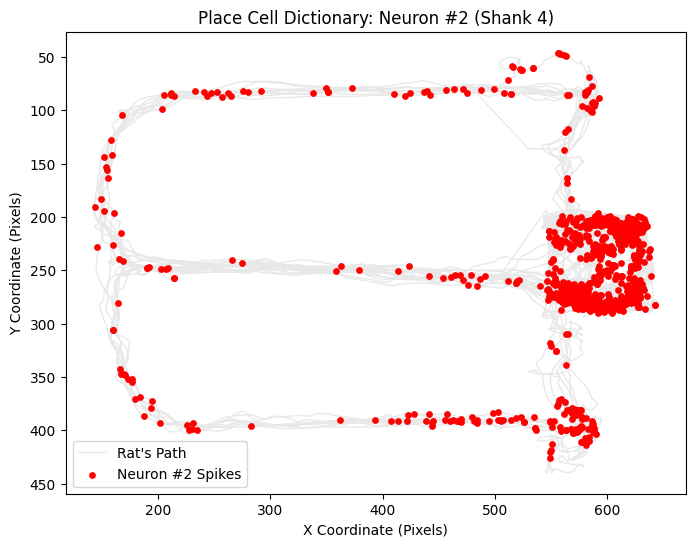

In [ ]:
#testing a single neuron's firing across the map, neuron 2 shank 3

import numpy as np
import matplotlib.pyplot as plt
import glob

# 1. Load the wheel data again (the map)
whl_file = glob.glob('**/*.187.whl', recursive=True)[0]
whl_data = np.loadtxt(whl_file)
x = whl_data[:, 0]
y = whl_data[:, 1]

# 2. Find the Spikes (.res) and Clusters (.clu)
# We will dynamically find the first available "Shank" (electrode group)
res_file = glob.glob('**/*.187.res.*', recursive=True)[0]
shank_num = res_file.split('.')[-1] # Gets the shank number (e.g., '1' or '3')
clu_file = res_file.replace('.res.', '.clu.')

print(f"Extracting memory data from Electrode Shank #{shank_num}...")

# 3. Load the data into memory
# .res contains timestamps recorded at a blazing 20,000 Hz
timestamps = np.loadtxt(res_file)

# .clu contains the Neuron IDs.
# (The first row is just the total count of neurons, so we slice it off with [1:])
cluster_ids = np.loadtxt(clu_file)[1:]

# 4. Isolate a single neuron's voice
# (IDs 0 and 1 are usually electrical garbage/noise. 2 is the first clean cell!)
neuron_id = 2
neuron_spikes = timestamps[cluster_ids == neuron_id]

print(f"Neuron #{neuron_id} fired a total of {len(neuron_spikes)} times.")

# 5. SYNCHRONIZE THE CLOCKS (The crucial neuro-engineering math)
# The brain data was recorded at 20,000 Hz.
# The camera data (.whl) was recorded at 39.0625 Hz.
# Therefore, 1 camera frame = exactly 512 brain samples (20000 / 39.0625).
# By dividing by 512, we convert brain time into camera time!
spike_frames = (neuron_spikes / 512).astype(int)

# Filter out any spikes that happened after the camera was turned off
spike_frames = spike_frames[spike_frames < len(x)]

# Get the exact X/Y coordinates for every spike
spike_x = x[spike_frames]
spike_y = y[spike_frames]

# Clean up any -1 tracking errors during those spikes
valid_spikes = (spike_x != -1) & (spike_y != -1)
spike_x = spike_x[valid_spikes]
spike_y = spike_y[valid_spikes]

# 6. DRAW THE MIND ON THE MAP
plt.figure(figsize=(8, 6))

# Draw the maze in light grey so it stays in the background
valid_whl = (x != -1) & (y != -1)
plt.plot(x[valid_whl], y[valid_whl], color='lightgrey', alpha=0.5, linewidth=1, label="Rat's Path")

# Overlay Neuron #2's spikes as bright red dots
plt.scatter(spike_x, spike_y, color='red', s=15, zorder=5, label=f"Neuron #{neuron_id} Spikes")

plt.title(f"Place Cell Dictionary: Neuron #{neuron_id} (Shank {shank_num})")
plt.xlabel("X Coordinate (Pixels)")
plt.ylabel("Y Coordinate (Pixels)")
plt.legend()
plt.gca().invert_yaxis()
plt.show()

In [ ]:
#counting # all neurons in # all shanks

import glob

# Find all the .res files and sort them mathematically
res_files = sorted(glob.glob('**/*.187.res.*', recursive=True))

print(f"Found {len(res_files)} electrode shanks in the brain!\n")

total_neurons_experiment = 0

for res in res_files:
    shank_num = res.split('.')[-1]
    clu_file = res.replace('.res.', '.clu.')

    # Open the clu file just to read the very first line (the cluster count)
    with open(clu_file, 'r') as f:
        total_clusters = int(f.readline().strip())

    real_neurons = total_clusters - 2 # Subtract the 2 noise clusters
    if real_neurons < 0: real_neurons = 0

    print(f"Shank #{shank_num}: {real_neurons} neurons found.")
    total_neurons_experiment += real_neurons

print(f"\nTotal neurons recorded today: {total_neurons_experiment}")

Found 4 electrode shanks in the brain!

Shank #1: 7 neurons found.
Shank #2: 9 neurons found.
Shank #3: 8 neurons found.
Shank #4: 2 neurons found.

Total neurons recorded today: 26


Total clusters found: 11
(Remember: 0 is noise, 1 is background chatter. Real neurons are 2 through 10)


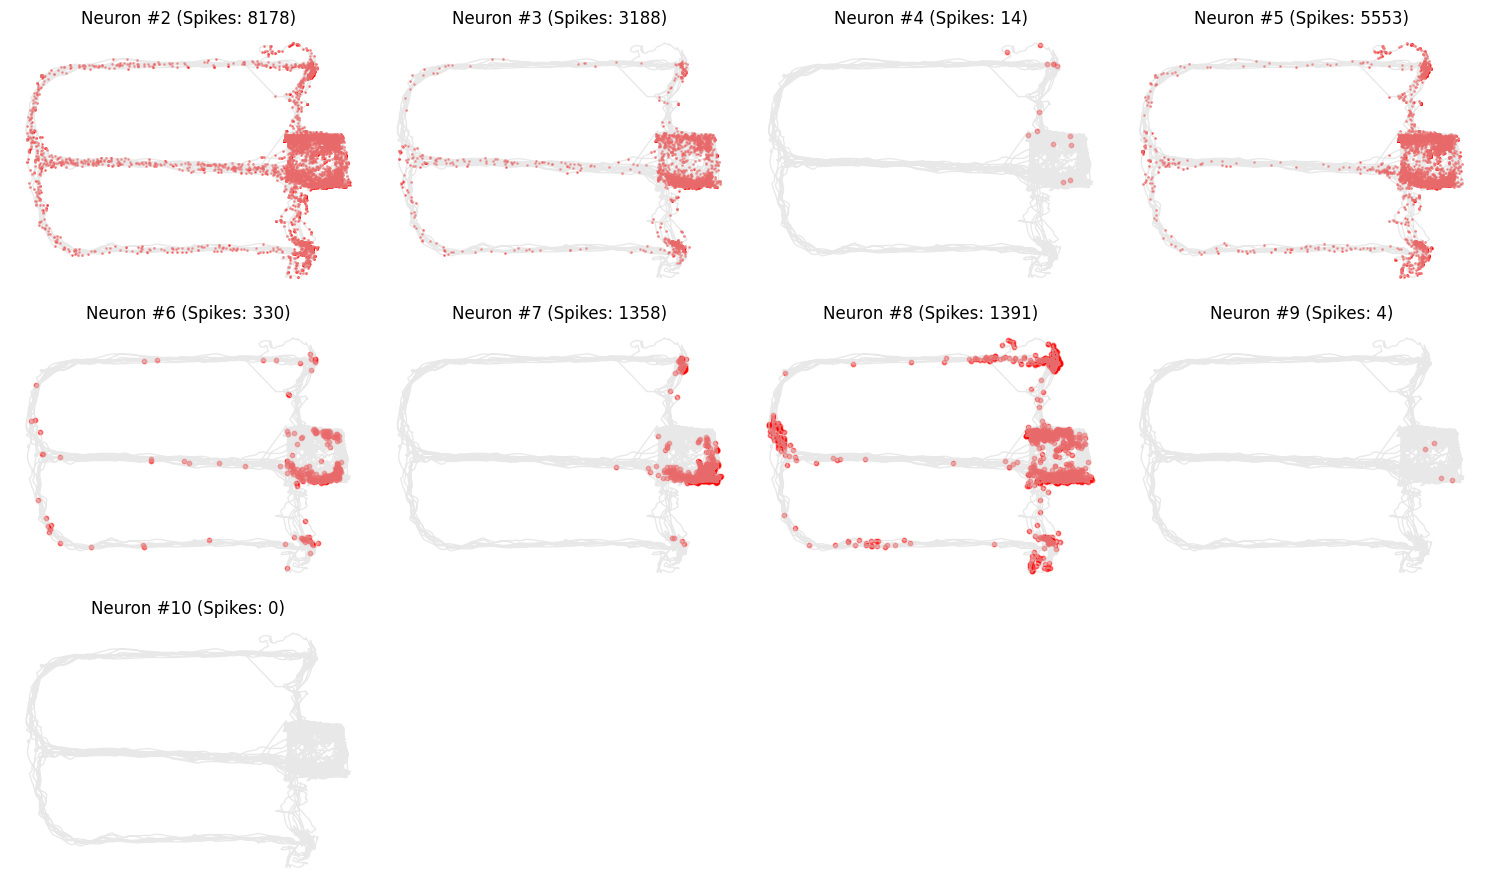

In [ ]:
# visualize all neurons within one shank

import numpy as np
import matplotlib.pyplot as plt
import glob
import math

# 1. Load the Maze Map
whl_file = glob.glob('**/*.187.whl', recursive=True)[0]
whl_data = np.loadtxt(whl_file)
x = whl_data[:, 0]
y = whl_data[:, 1]

# 2. Find the Spike and Cluster files
res_file = glob.glob('**/*.187.res.2', recursive=True)[0]
clu_file = res_file.replace('.res.', '.clu.')

timestamps = np.loadtxt(res_file)
cluster_data = np.loadtxt(clu_file)

# 3. EXACTLY HOW MANY NEURONS ARE THERE?
# The very first number in the clu file is the total cluster count
total_clusters = int(cluster_data[0])
cluster_ids = cluster_data[1:] # The rest are the actual spike IDs

print(f"Total clusters found: {total_clusters}")
print(f"(Remember: 0 is noise, 1 is background chatter. Real neurons are 2 through {total_clusters - 1})")

# Find how many real neurons we have to plot
real_neurons = range(2, total_clusters)
num_real_neurons = len(real_neurons)

# 4. SET UP A VISUAL GRID
# Calculate how many rows and columns we need for our subplots
cols = 4
rows = math.ceil(num_real_neurons / cols)
fig, axes = plt.subplots(rows, cols, figsize=(15, 3 * rows))
axes = axes.flatten()

# 5. LOOP THROUGH EVERY SINGLE NEURON
for i, neuron_id in enumerate(real_neurons):
    ax = axes[i]

    # Isolate this specific neuron's spikes
    neuron_spikes = timestamps[cluster_ids == neuron_id]

    # Synchronize brain time (20kHz) to camera time (~39Hz)
    spike_frames = (neuron_spikes / 512).astype(int)
    spike_frames = spike_frames[spike_frames < len(x)]

    spike_x = x[spike_frames]
    spike_y = y[spike_frames]

    # Clean up tracking errors
    valid_spikes = (spike_x != -1) & (spike_y != -1)
    spike_x = spike_x[valid_spikes]
    spike_y = spike_y[valid_spikes]

    # Draw the map
    valid_whl = (x != -1) & (y != -1)
    ax.plot(x[valid_whl], y[valid_whl], color='lightgrey', alpha=0.5, linewidth=1)

    # If the neuron fired too much (like an interneuron), plot it smaller to see the maze
    dot_size = 10 if len(spike_x) < 2000 else 1
    ax.scatter(spike_x, spike_y, color='red', s=dot_size, alpha=0.5)

    ax.set_title(f"Neuron #{neuron_id} (Spikes: {len(spike_x)})")
    ax.invert_yaxis()
    ax.axis('off') # Hide axes to make the grid cleaner

# Remove any empty subplot panels
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

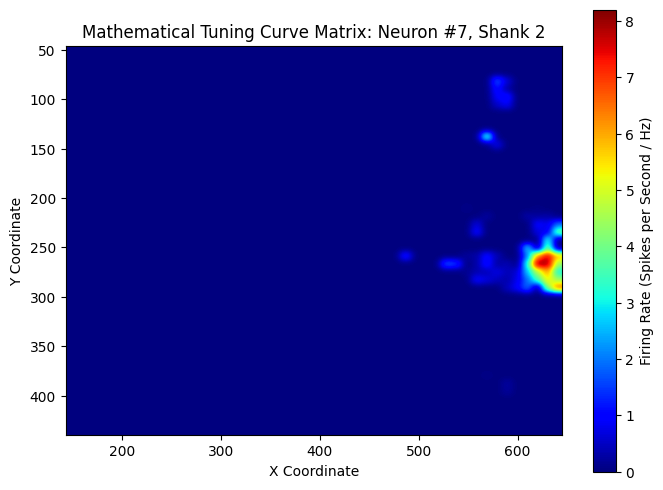

When the rat enters this neuron's place field, it fires at a peak rate of: 8.20 Hz!


In [ ]:
#for one neuron, plot firing rate in area

import numpy as np
import matplotlib.pyplot as plt
import glob

# 1. Load the tracking data (.whl)
whl_file = glob.glob('**/*.187.whl', recursive=True)[0]
whl_data = np.loadtxt(whl_file)
x = whl_data[:, 0]
y = whl_data[:, 1]

# 2. Load the Spike data for Shank 2, Neuron 7
# (Make sure this matches the shank where you found Neuron 7!)
res_file = glob.glob('**/*.187.res.2', recursive=True)[0]
clu_file = res_file.replace('.res.', '.clu.')

timestamps = np.loadtxt(res_file)
cluster_ids = np.loadtxt(clu_file)[1:]

neuron_id = 7
neuron_spikes = timestamps[cluster_ids == neuron_id]

# Synchronize brain clocks to camera frames
spike_frames = (neuron_spikes / 512).astype(int)
spike_frames = spike_frames[spike_frames < len(x)]
spike_x = x[spike_frames]
spike_y = y[spike_frames]

# Filter out tracking errors (-1) from both tracking and spikes
valid_whl = (x != -1) & (y != -1)
x_clean = x[valid_whl]
y_clean = y[valid_whl]

valid_spikes = (spike_x != -1) & (spike_y != -1)
spike_x_clean = spike_x[valid_spikes]
spike_y_clean = spike_y[valid_spikes]

# =======================================================
# 3. MATHEMATICAL BINNING (Creating the Grid)
# =======================================================
# Define the boundaries of the maze based on camera pixels
x_edges = np.linspace(np.min(x_clean), np.max(x_clean), 50)
y_edges = np.linspace(np.min(y_clean), np.max(y_clean), 50)

# Map A: Count the raw spikes in each grid bin
spike_matrix, _, _ = np.histogram2d(spike_x_clean, spike_y_clean, bins=[x_edges, y_edges])

# Map B: Count how many video frames the rat spent in each grid bin
occupancy_matrix, _, _ = np.histogram2d(x_clean, y_clean, bins=[x_edges, y_edges])

# Convert video frames into actual seconds
# The camera records at 39.0625 frames per second, so 1 frame = 1 / 39.0625 seconds
occupancy_seconds = occupancy_matrix / 39.0625

# Map C: Calculate Firing Rate (Spikes / Seconds)
# To avoid dividing by zero where the rat never walked, we use np.where
firing_rate_map = np.zeros_like(spike_matrix)
nonzero_occupancy = occupancy_seconds > 0
firing_rate_map[nonzero_occupancy] = spike_matrix[nonzero_occupancy] / occupancy_seconds[nonzero_occupancy]

# =======================================================
# 4. PLOT THE MATHEMATICAL DICTIONARY ENTRY
# =======================================================
plt.figure(figsize=(8, 6))
# Transpose the map (.T) so it aligns correctly with the X and Y axes
plt.imshow(firing_rate_map.T, origin='lower', cmap='jet', interpolation='gaussian',
           extent=[x_edges[0], x_edges[-1], y_edges[0], y_edges[-1]])

plt.colorbar(label="Firing Rate (Spikes per Second / Hz)")
plt.title(f"Mathematical Tuning Curve Matrix: Neuron #{neuron_id}, Shank 2")
plt.xlabel("X Coordinate")
plt.ylabel("Y Coordinate")
plt.gca().invert_yaxis() # Maintain consistency with camera coordinates
plt.show()

# Print the maximum firing rate for verification
print(f"When the rat enters this neuron's place field, it fires at a peak rate of: {np.max(firing_rate_map):.2f} Hz!")

In this 250ms window, Neuron 7 fired exactly 0 spikes.


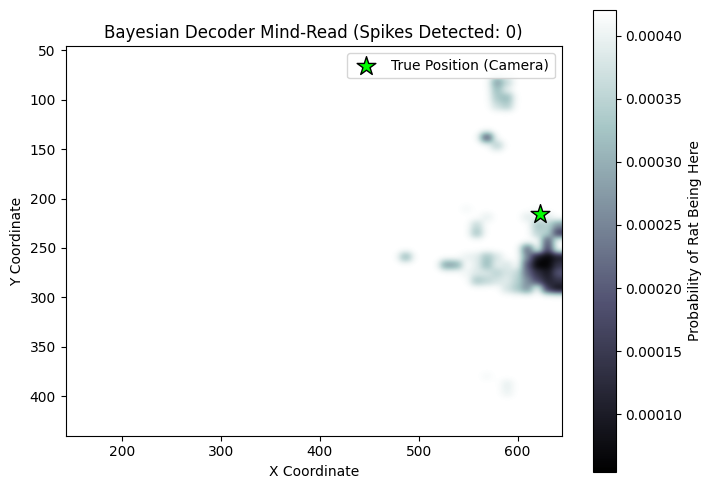

In [ ]:
# bayesian decoder, test to see if true position matches prediction given a specific time's neuron spikes

import numpy as np
import matplotlib.pyplot as plt

# 1. Choose a time window to decode (in seconds)
# Let's pick a moment around 500 seconds into the experiment
start_second = 500.0
window_length = 0.250 # 250 milliseconds

# Convert seconds to brain time (20,000 Hz clock)
window_start_ticks = start_second * 20000
window_end_ticks = (start_second + window_length) * 20000

# 2. Count how many spikes Neuron 7 fired in this exact window
spikes_in_window = neuron_spikes[(neuron_spikes >= window_start_ticks) & (neuron_spikes < window_end_ticks)]
n = len(spikes_in_window)

print(f"In this 250ms window, Neuron 7 fired exactly {n} spikes.")

# 3. RUN THE BAYESIAN DECODER MATH
# We will compute the posterior probability for every bin in our 50x50 map
tau = window_length

# Term 1: The activation reward (f(x)^n)
# We add a tiny offset (1e-10) to avoid any mathematical errors with 0
power_term = np.power(firing_rate_map, n)

# Term 2: The silence penalty (e^-tau*f(x))
exp_term = np.exp(-tau * firing_rate_map)

# Combine them to get the raw probability landscape
posterior = power_term * exp_term

# Normalize the map so all probabilities add up to 100%
if np.sum(posterior) > 0:
    posterior = posterior / np.sum(posterior)

# 4. FIND GROUND TRUTH (Where was the rat actually?)
# Convert start_second to camera frames (~39.0625 Hz)
actual_frame = int(start_second * 39.0625)
actual_x = x[actual_frame]
actual_y = y[actual_frame]

# 5. PLOT THE COMPUTER'S GUESS VS REALITY
plt.figure(figsize=(8, 6))

# Plot the Bayesian probability landscape
plt.imshow(posterior.T, origin='lower', cmap='bone', interpolation='gaussian',
           extent=[x_edges[0], x_edges[-1], y_edges[0], y_edges[-1]])
plt.colorbar(label="Probability of Rat Being Here")

# Overlay the ACTUAL position of the rat as a green star
if actual_x != -1 and actual_y != -1:
    plt.scatter(actual_x, actual_y, color='lime', marker='*', s=200, edgecolors='black',
                zorder=10, label="True Position (Camera)")

plt.title(f"Bayesian Decoder Mind-Read (Spikes Detected: {n})")
plt.xlabel("X Coordinate")
plt.ylabel("Y Coordinate")
plt.legend()
plt.gca().invert_yaxis()
plt.show()

Target Acquired: In this 250ms window, Neuron 7 fired 1 spikes!


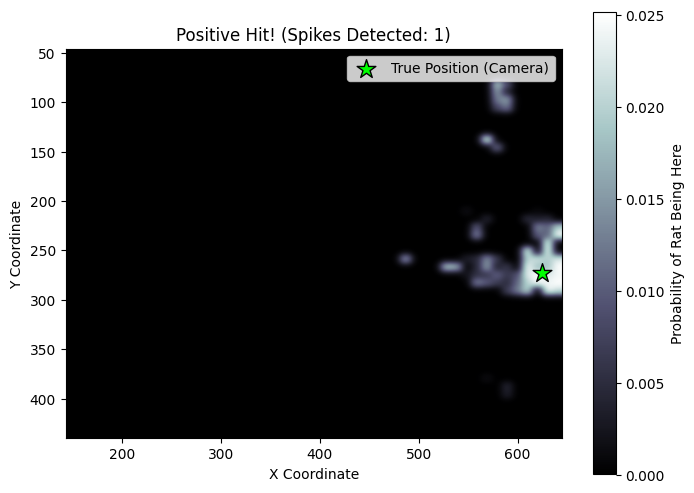

In [ ]:
# bayesian decoder, test again but using time that is known to be within neuron's spike area

import numpy as np
import matplotlib.pyplot as plt

# 1. TARGET A CONFIRMED SPIKE
# Let's grab the timestamp of Neuron 7's 150th spike (well into the session)
spike_time_seconds = neuron_spikes[150] / 20000.0

# Center our 250ms window exactly around this spike
start_second = spike_time_seconds - 0.125
window_length = 0.250

# Convert to brain clock ticks
window_start_ticks = start_second * 20000
window_end_ticks = (start_second + window_length) * 20000

# 2. Count the spikes
spikes_in_window = neuron_spikes[(neuron_spikes >= window_start_ticks) & (neuron_spikes < window_end_ticks)]
n = len(spikes_in_window)

print(f"Target Acquired: In this 250ms window, Neuron 7 fired {n} spikes!")

# 3. RUN THE BAYESIAN DECODER MATH
tau = window_length
power_term = np.power(firing_rate_map + 1e-10, n) # Tiny offset prevents 0^n math errors
exp_term = np.exp(-tau * firing_rate_map)

posterior = power_term * exp_term

if np.sum(posterior) > 0:
    posterior = posterior / np.sum(posterior)

# 4. FIND GROUND TRUTH
actual_frame = int(start_second * 39.0625)
actual_x = x[actual_frame]
actual_y = y[actual_frame]

# 5. PLOT IT
plt.figure(figsize=(8, 6))

plt.imshow(posterior.T, origin='lower', cmap='bone', interpolation='gaussian',
           extent=[x_edges[0], x_edges[-1], y_edges[0], y_edges[-1]])
plt.colorbar(label="Probability of Rat Being Here")

if actual_x != -1 and actual_y != -1:
    plt.scatter(actual_x, actual_y, color='lime', marker='*', s=200, edgecolors='black',
                zorder=10, label="True Position (Camera)")

plt.title(f"Positive Hit! (Spikes Detected: {n})")
plt.xlabel("X Coordinate")
plt.ylabel("Y Coordinate")
plt.legend()
plt.gca().invert_yaxis()
plt.show()

In [ ]:
#load sleep data

!tar -xvzf /content/drive/MyDrive/hc3_data/ec012ec.188.tar.gz

ec012ec.11/ec012ec.188/ec012ec.188.clu.1
ec012ec.11/ec012ec.188/ec012ec.188.clu.2
ec012ec.11/ec012ec.188/ec012ec.188.clu.3
ec012ec.11/ec012ec.188/ec012ec.188.clu.4
ec012ec.11/ec012ec.188/ec012ec.188.eeg
ec012ec.11/ec012ec.188/ec012ec.188.fet.1
ec012ec.11/ec012ec.188/ec012ec.188.fet.2
ec012ec.11/ec012ec.188/ec012ec.188.fet.3
ec012ec.11/ec012ec.188/ec012ec.188.fet.4
ec012ec.11/ec012ec.188/ec012ec.188.m1m2.1
ec012ec.11/ec012ec.188/ec012ec.188.m1m2.2
ec012ec.11/ec012ec.188/ec012ec.188.m1m2.3
ec012ec.11/ec012ec.188/ec012ec.188.m1m2.4
ec012ec.11/ec012ec.188/ec012ec.188.m1v
ec012ec.11/ec012ec.188/ec012ec.188.mm.1
ec012ec.11/ec012ec.188/ec012ec.188.mm.2
ec012ec.11/ec012ec.188/ec012ec.188.mm.3
ec012ec.11/ec012ec.188/ec012ec.188.mm.4
ec012ec.11/ec012ec.188/ec012ec.188.res.1
ec012ec.11/ec012ec.188/ec012ec.188.res.2
ec012ec.11/ec012ec.188/ec012ec.188.res.3
ec012ec.11/ec012ec.188/ec012ec.188.res.4
ec012ec.11/ec012ec.188/ec012ec.188.spk.1
ec012ec.11/ec012ec.188/ec012ec.188.spk.2
ec012ec.11/ec012ec.1

Neuron 7 fired a total of 150 times while the rat slept.
Dream Caught! Found a split-second window where Neuron 7 fired 5 spikes.


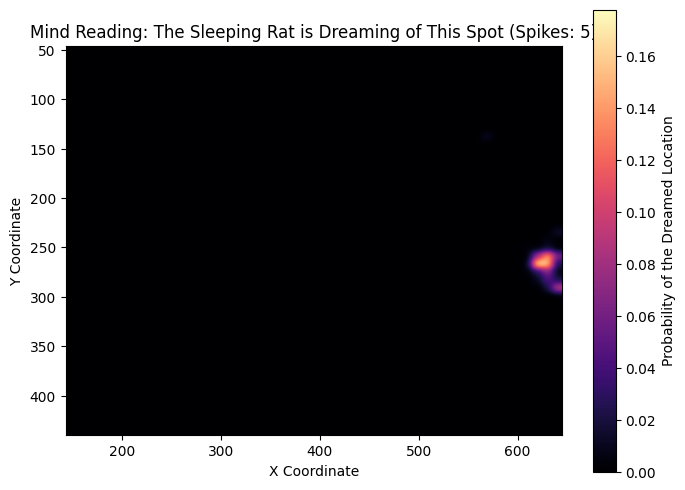

In [ ]:
#use sleep data, get neuron 7, highest firing rate period, use spikes to predict location

import numpy as np
import matplotlib.pyplot as plt
import glob

# 1. Load the Sleep Data (.188) for Shank 2
res_file_sleep = glob.glob('**/*.188.res.2', recursive=True)[0]
clu_file_sleep = res_file_sleep.replace('.res.', '.clu.')

timestamps_sleep = np.loadtxt(res_file_sleep)
cluster_ids_sleep = np.loadtxt(clu_file_sleep)[1:]

# Isolate Neuron 7's sleep spikes
neuron_id = 7
sleep_spikes = timestamps_sleep[cluster_ids_sleep == neuron_id]

print(f"Neuron {neuron_id} fired a total of {len(sleep_spikes)} times while the rat slept.")

# 2. Hunt for a Memory Replay Burst (Sharp-Wave Ripple)
# We will scan the night to find the densest 250ms window of firing.
window_ticks = 0.250 * 20000 # 250ms in brain time clock ticks
best_burst_count = 0

# Quick scan to find the densest burst
for i in range(len(sleep_spikes) - 1):
    start_tick = sleep_spikes[i]
    end_tick = start_tick + window_ticks

    # Count how many spikes happened in this tiny window
    spikes_in_burst = np.sum((sleep_spikes >= start_tick) & (sleep_spikes < end_tick))

    if spikes_in_burst > best_burst_count:
        best_burst_count = spikes_in_burst

n = best_burst_count
print(f"Dream Caught! Found a split-second window where Neuron 7 fired {n} spikes.")

# 3. RUN THE BAYESIAN DECODER
# (Using the firing_rate_map we built from the awake session!)
tau = 0.250
power_term = np.power(firing_rate_map + 1e-10, n)
exp_term = np.exp(-tau * firing_rate_map)

posterior = power_term * exp_term

if np.sum(posterior) > 0:
    posterior = posterior / np.sum(posterior)

# 4. PLOT THE DREAM
plt.figure(figsize=(8, 6))

# We use the 'magma' color map for sleep data—it looks like a glowing memory in the dark!
plt.imshow(posterior.T, origin='lower', cmap='magma', interpolation='gaussian',
           extent=[x_edges[0], x_edges[-1], y_edges[0], y_edges[-1]])
plt.colorbar(label="Probability of the Dreamed Location")

plt.title(f"Mind Reading: The Sleeping Rat is Dreaming of This Spot (Spikes: {n})")
plt.xlabel("X Coordinate")
plt.ylabel("Y Coordinate")
plt.gca().invert_yaxis()
plt.show()

In [ ]:
# use awake data, build 3d matrix using x and y coordinates and all 26 neurons

import numpy as np
import matplotlib.pyplot as plt
import glob

# 1. Load the Maze Tracking Data (Awake Session)
whl_file = glob.glob('**/*.187.whl', recursive=True)[0]
whl_data = np.loadtxt(whl_file)
x = whl_data[:, 0]
y = whl_data[:, 1]

valid_whl = (x != -1) & (y != -1)
x_clean = x[valid_whl]
y_clean = y[valid_whl]

# 2. Set up the universal 50x50 Spatial Grid
x_edges = np.linspace(np.min(x_clean), np.max(x_clean), 50)
y_edges = np.linspace(np.min(y_clean), np.max(y_clean), 50)

# Calculate universal occupancy (how long rat spent in each bin)
occupancy_matrix, _, _ = np.histogram2d(x_clean, y_clean, bins=[x_edges, y_edges])
occupancy_seconds = occupancy_matrix / 39.0625
nonzero_occupancy = occupancy_seconds > 0

# 3. LOOP THROUGH ALL ELECTRODES AND BUILD THE 3D DICTIONARY
res_files = sorted(glob.glob('**/*.187.res.*', recursive=True))

master_tuning_curves = [] # This will hold all 26 maps
neuron_roster = [] # Keeps track of who is who (Shank #, Neuron ID)

print("Compiling Master Population Dictionary...")

for res_file in res_files:
    shank_num = res_file.split('.')[-1]
    clu_file = res_file.replace('.res.', '.clu.')

    timestamps = np.loadtxt(res_file)
    cluster_data = np.loadtxt(clu_file)
    total_clusters = int(cluster_data[0])
    cluster_ids = cluster_data[1:]

    # Loop through every real neuron (skipping 0 and 1)
    for neuron_id in range(2, total_clusters):
        neuron_spikes = timestamps[cluster_ids == neuron_id]

        # Synchronize and clean
        spike_frames = (neuron_spikes / 512).astype(int)
        spike_frames = spike_frames[spike_frames < len(x)]
        spike_x = x[spike_frames]
        spike_y = y[spike_frames]

        valid_spikes = (spike_x != -1) & (spike_y != -1)

        # Count spikes in the grid
        spike_matrix, _, _ = np.histogram2d(spike_x[valid_spikes], spike_y[valid_spikes], bins=[x_edges, y_edges])

        # Calculate Hz
        firing_rate_map = np.zeros_like(spike_matrix)
        firing_rate_map[nonzero_occupancy] = spike_matrix[nonzero_occupancy] / occupancy_seconds[nonzero_occupancy]

        master_tuning_curves.append(firing_rate_map)
        neuron_roster.append(f"Shank {shank_num}-Cell {neuron_id}")

# Convert our list of maps into a pure 3D NumPy matrix
master_tuning_curves = np.array(master_tuning_curves)

print(f"\nDictionary Complete! Matrix Shape: {master_tuning_curves.shape}")
print(f"(Expected shape: [26, 50, 50] -> Neurons, X-bins, Y-bins)")

Compiling Master Population Dictionary...

Dictionary Complete! Matrix Shape: (26, 49, 49)
(Expected shape: [26, 50, 50] -> Neurons, X-bins, Y-bins)


Total spikes across all 26 neurons in this window: 0


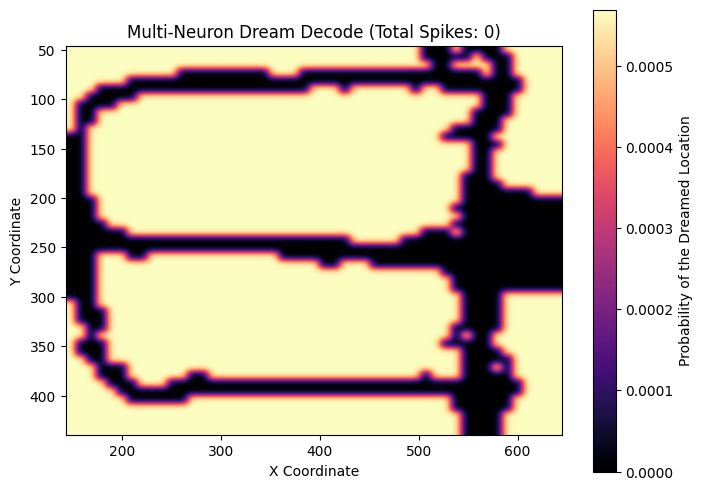

In [ ]:
#pick a random moment during sleep and run decoder on whole matrix

import numpy as np
import matplotlib.pyplot as plt
import glob

# 1. Load the Sleep Data for ALL Shanks
res_files_sleep = sorted(glob.glob('**/*.188.res.*', recursive=True))

# Choose an arbitrary time window during the night to scan for a dream
# (e.g., 5000 seconds into the sleep phase)
start_second = 5000.0
window_length = 0.250
window_start_ticks = start_second * 20000
window_end_ticks = (start_second + window_length) * 20000

# 2. Build the Population Vector (Count spikes for all 26 neurons)
population_vector = []

for res_file in res_files_sleep:
    clu_file = res_file.replace('.res.', '.clu.')
    timestamps_sleep = np.loadtxt(res_file)

    cluster_data = np.loadtxt(clu_file)
    total_clusters = int(cluster_data[0])
    cluster_ids_sleep = cluster_data[1:]

    for neuron_id in range(2, total_clusters):
        neuron_spikes = timestamps_sleep[cluster_ids_sleep == neuron_id]

        # Count spikes for this specific neuron in our time window
        spikes_in_window = np.sum((neuron_spikes >= window_start_ticks) & (neuron_spikes < window_end_ticks))
        population_vector.append(spikes_in_window)

# Convert to a NumPy array for math
population_vector = np.array(population_vector)
total_spikes_in_burst = np.sum(population_vector)
print(f"Total spikes across all 26 neurons in this window: {total_spikes_in_burst}")

# 3. RUN THE MULTI-VARIABLE BAYESIAN DECODER
# Start with a flat prior (equal probability everywhere)
posterior = np.ones((49, 49))
tau = window_length

# Multiply the probability maps of all 26 neurons together
for i in range(26):
    n_i = population_vector[i]
    f_i = master_tuning_curves[i]

    # Power term: f_i(x)^n_i
    power_term = np.power(f_i + 1e-10, n_i)
    # Silence penalty: exp(-tau * f_i(x))
    exp_term = np.exp(-tau * f_i)

    posterior *= (power_term * exp_term)

# Normalize the final map
if np.sum(posterior) > 0:
    posterior = posterior / np.sum(posterior)

# 4. PLOT THE POPULATION DREAM MAP
plt.figure(figsize=(8, 6))
plt.imshow(posterior.T, origin='lower', cmap='magma', interpolation='gaussian',
           extent=[x_edges[0], x_edges[-1], y_edges[0], y_edges[-1]])
plt.colorbar(label="Probability of the Dreamed Location")

plt.title(f"Multi-Neuron Dream Decode (Total Spikes: {total_spikes_in_burst})")
plt.xlabel("X Coordinate")
plt.ylabel("Y Coordinate")
plt.gca().invert_yaxis()
plt.show()

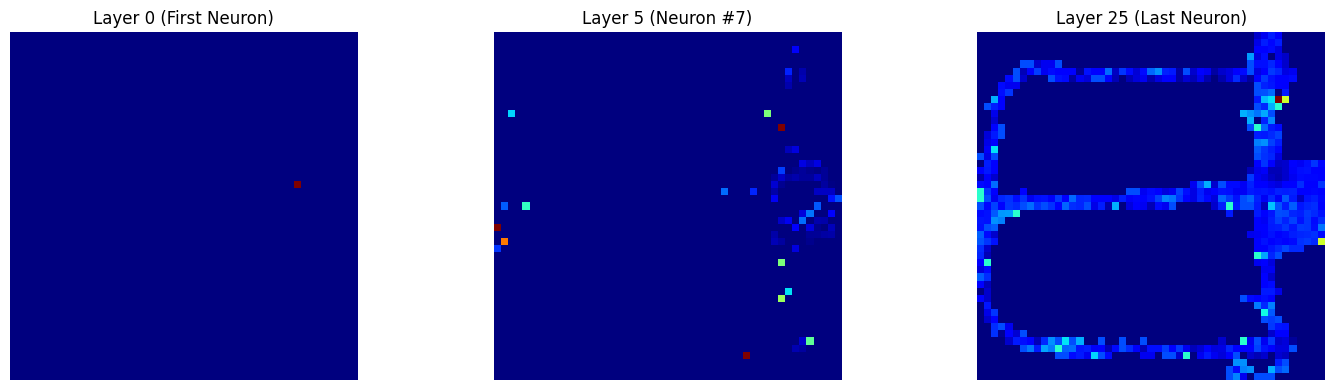

In [ ]:
#individual layer visualization

import matplotlib.pyplot as plt

# We are going to slice into our 3D matrix and pull out 3 specific layers
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Slice 1: Floor 0 (The very first neuron we processed)
im0 = axes[0].imshow(master_tuning_curves[0].T, origin='lower', cmap='jet')
axes[0].set_title("Layer 0 (First Neuron)")
axes[0].axis('off')

# Slice 2: Floor 5 (This is Neuron #7, your jackpot cell!)
im1 = axes[1].imshow(master_tuning_curves[5].T, origin='lower', cmap='jet')
axes[1].set_title("Layer 5 (Neuron #7)")
axes[1].axis('off')

# Slice 3: Floor 25 (The very last neuron in the matrix)
im2 = axes[2].imshow(master_tuning_curves[25].T, origin='lower', cmap='jet')
axes[2].set_title("Layer 25 (Last Neuron)")
axes[2].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# purging interneurons

import numpy as np

place_cell_indices = []
interneuron_indices = []
filtered_tuning_curves = []

# We'll use a standard threshold: If a neuron's average firing rate
# across the whole maze is higher than 5 Hz, it's an interneuron.
threshold_hz = 5.0

for i in range(26):
    # Get this specific neuron's 2D map
    neuron_map = master_tuning_curves[i]

    # Calculate its average firing rate (ignoring the empty 0s where the rat never walked)
    active_pixels = neuron_map[neuron_map > 0]

    # If the neuron didn't fire at all, safe to ignore, but we'll check the mean of active pixels
    if len(active_pixels) > 0:
        mean_rate = np.mean(active_pixels)
    else:
        mean_rate = 0

    if mean_rate < threshold_hz:
        # It's a Place Cell! Keep it.
        place_cell_indices.append(i)
        filtered_tuning_curves.append(neuron_map)
    else:
        # It's an Interneuron! Drop it.
        interneuron_indices.append(i)

# Convert our cleansed list back into a pure 3D NumPy matrix
filtered_tuning_curves = np.array(filtered_tuning_curves)

print("--- PURGE COMPLETE ---")
print(f"Original Population: 26 neurons")
print(f"Place Cells (Kept): {len(place_cell_indices)} neurons")
print(f"Interneurons (Destroyed): {len(interneuron_indices)} neurons")
print(f"New Master Dictionary Shape: {filtered_tuning_curves.shape}")

--- PURGE COMPLETE ---
Original Population: 26 neurons
Place Cells (Kept): 16 neurons
Interneurons (Destroyed): 10 neurons
New Master Dictionary Shape: (16, 49, 49)


In [ ]:
import numpy as np

# Define the save paths in your Drive
matrix_path = '/content/drive/MyDrive/master_tuning_curves.npy'
x_edges_path = '/content/drive/MyDrive/x_edges.npy'
y_edges_path = '/content/drive/MyDrive/y_edges.npy'

# Save the mathematical objects
np.save(matrix_path, master_tuning_curves)
np.save(x_edges_path, x_edges)
np.save(y_edges_path, y_edges)

print("Checkpoint Saved! Your mathematical dictionary is permanently stored.")

Checkpoint Saved! Your mathematical dictionary is permanently stored.


REAL Target Acquired! At exactly 25.50 seconds into sleep,
the 16 Place Cells exploded with 11 pure spatial spikes in just 250ms!


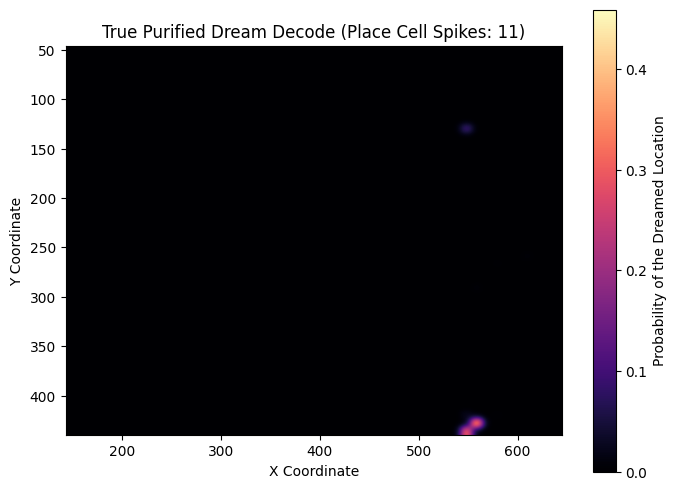

In [ ]:
# generate location plot using only place cells

import numpy as np
import matplotlib.pyplot as plt
import glob

# 1. READ THE RAW SLEEP DATA (.188 files)
res_files_sleep = sorted(glob.glob('**/*.188.res.*', recursive=True))

neuron_spike_lists = [] # Rebuilding the lost list

for res_file in res_files_sleep:
    clu_file = res_file.replace('.res.', '.clu.')
    timestamps_sleep = np.loadtxt(res_file)
    cluster_data = np.loadtxt(clu_file)
    total_clusters = int(cluster_data[0])
    cluster_ids_sleep = cluster_data[1:]

    for neuron_id in range(2, total_clusters):
        neuron_spikes = timestamps_sleep[cluster_ids_sleep == neuron_id]
        neuron_spike_lists.append(neuron_spikes)

# 2. GATHER SLEEP SPIKES ONLY FROM THE 16 PLACE CELLS
purified_sleep_spikes = []
for idx in place_cell_indices:
    purified_sleep_spikes.extend(neuron_spike_lists[idx])

purified_sleep_spikes = np.array(purified_sleep_spikes)

# 3. RE-SCAN THE NIGHT TO FIND THE TRUE LOUDEST 250ms WINDOW
window_ticks = 0.250 * 20000
max_tick = np.max(purified_sleep_spikes)

bins = np.arange(0, max_tick + window_ticks, window_ticks)
hist, bin_edges = np.histogram(purified_sleep_spikes, bins=bins)

best_bin_index = np.argmax(hist)
true_best_start_tick = bin_edges[best_bin_index]
true_best_end_tick = bin_edges[best_bin_index + 1]
true_best_spike_count = hist[best_bin_index]

true_best_time_seconds = true_best_start_tick / 20000.0

print(f"REAL Target Acquired! At exactly {true_best_time_seconds:.2f} seconds into sleep,")
print(f"the 16 Place Cells exploded with {true_best_spike_count} pure spatial spikes in just 250ms!")

# 4. BUILD THE POPULATION VECTOR FOR THIS NEW WINDOW
true_population_vector = []
for idx in place_cell_indices:
    neuron_spikes = neuron_spike_lists[idx]
    spikes_in_burst = np.sum((neuron_spikes >= true_best_start_tick) & (neuron_spikes < true_best_end_tick))
    true_population_vector.append(spikes_in_burst)

true_population_vector = np.array(true_population_vector)

# 5. RUN THE PURIFIED 3D BAYESIAN DECODER
posterior_clean = np.ones((49, 49))
tau = 0.250

for i in range(len(place_cell_indices)):
    n_i = true_population_vector[i]
    f_i = filtered_tuning_curves[i]

    power_term = np.power(f_i + 1e-10, n_i)
    exp_term = np.exp(-tau * f_i)
    posterior_clean *= (power_term * exp_term)

if np.sum(posterior_clean) > 0:
    posterior_clean = posterior_clean / np.sum(posterior_clean)

# 6. PLOT THE TRUE DREAM
plt.figure(figsize=(8, 6))
plt.imshow(posterior_clean.T, origin='lower', cmap='magma', interpolation='gaussian',
           extent=[x_edges[0], x_edges[-1], y_edges[0], y_edges[-1]])
plt.colorbar(label="Probability of the Dreamed Location")

plt.title(f"True Purified Dream Decode (Place Cell Spikes: {true_best_spike_count})")
plt.xlabel("X Coordinate")
plt.ylabel("Y Coordinate")
plt.gca().invert_yaxis()
plt.show()

--- THE TOP 5 SLEEP BURSTS ---
Rank 1: Occurred at 25.50 seconds with 11 pure spikes.
Rank 2: Occurred at 64.75 seconds with 8 pure spikes.
Rank 3: Occurred at 37.75 seconds with 8 pure spikes.
Rank 4: Occurred at 26.00 seconds with 8 pure spikes.
Rank 5: Occurred at 140.00 seconds with 8 pure spikes.


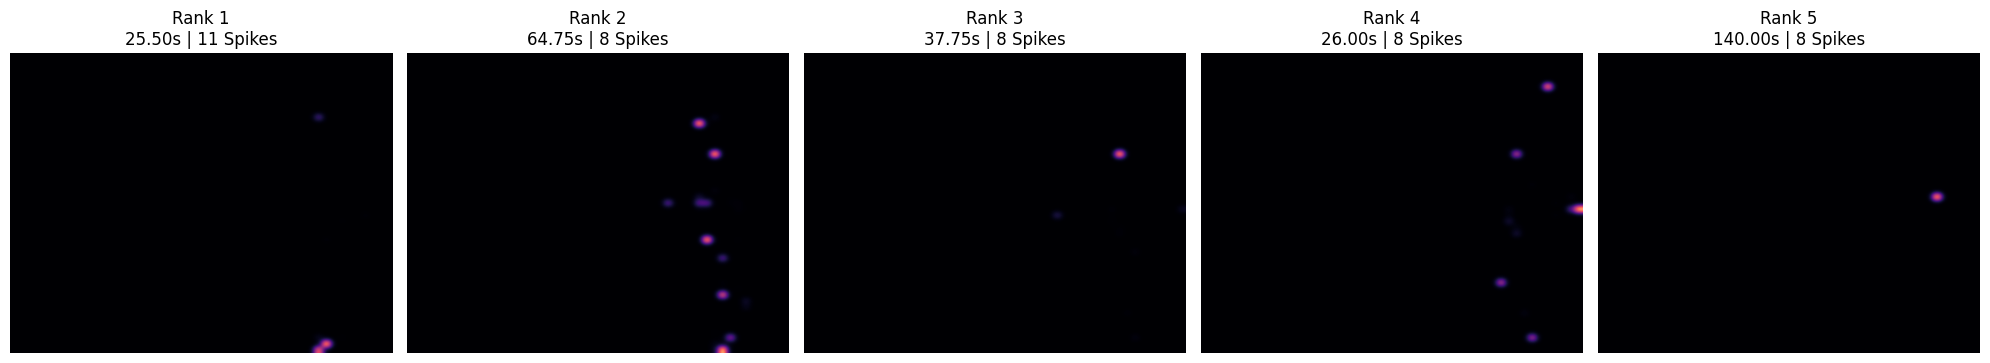

In [ ]:
# generate for top 5

import numpy as np
import matplotlib.pyplot as plt

# 1. Find the Top 5 bins with the most spikes
# argsort sorts from smallest to largest, so we take the last 5 and reverse them
top_5_indices = np.argsort(hist)[-5:][::-1]

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
tau = 0.250

print("--- THE TOP 5 SLEEP BURSTS ---")

for rank, bin_idx in enumerate(top_5_indices):
    start_tick = bin_edges[bin_idx]
    end_tick = bin_edges[bin_idx + 1]
    spike_count = int(hist[bin_idx])
    time_seconds = start_tick / 20000.0

    print(f"Rank {rank+1}: Occurred at {time_seconds:.2f} seconds with {spike_count} pure spikes.")

    # 2. Build the population vector for this specific burst
    pop_vector = []
    for idx in place_cell_indices:
        neuron_spikes = neuron_spike_lists[idx]
        spikes_in_burst = np.sum((neuron_spikes >= start_tick) & (neuron_spikes < end_tick))
        pop_vector.append(spikes_in_burst)

    # 3. Run the Bayesian Decode
    posterior = np.ones((49, 49))
    for i in range(len(place_cell_indices)):
        n_i = pop_vector[i]
        f_i = filtered_tuning_curves[i]

        power_term = np.power(f_i + 1e-10, n_i)
        exp_term = np.exp(-tau * f_i)
        posterior *= (power_term * exp_term)

    if np.sum(posterior) > 0:
        posterior = posterior / np.sum(posterior)

    # 4. Plot the decoded memory
    axes[rank].imshow(posterior.T, origin='lower', cmap='magma', interpolation='gaussian',
                      extent=[x_edges[0], x_edges[-1], y_edges[0], y_edges[-1]])
    axes[rank].set_title(f"Rank {rank+1}\n{time_seconds:.2f}s | {spike_count} Spikes")
    axes[rank].axis('off')
    axes[rank].invert_yaxis()

plt.tight_layout()
plt.show()

Analyzing Rank 2 Burst (Start: 64.75s, End: 65.00s)


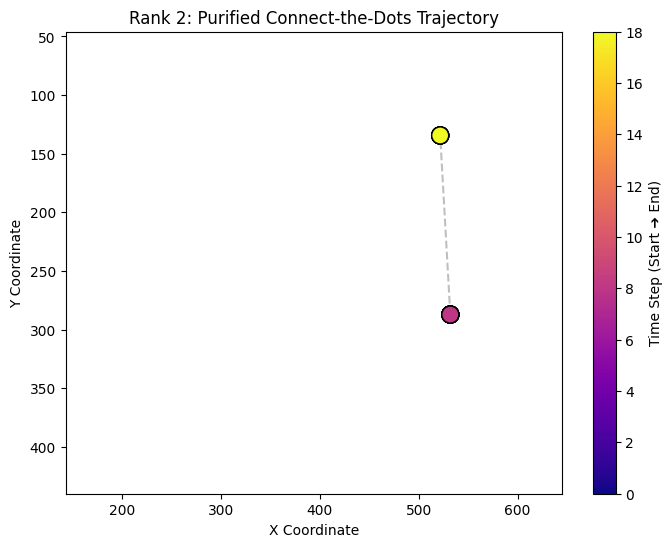

In [ ]:
# check to see if path can be drawn for rank 2, use sliding frames

import numpy as np
import matplotlib.pyplot as plt

# 1. Isolate the exact start and end time of Rank 2
# top_5_indices[1] is the 2nd highest peak (Rank 2)
rank2_bin_idx = top_5_indices[1]
start_tick = bin_edges[rank2_bin_idx]
end_tick = bin_edges[rank2_bin_idx + 1]

print(f"Analyzing Rank 2 Burst (Start: {start_tick/20000.0:.2f}s, End: {end_tick/20000.0:.2f}s)")

# 2. Set up the Sliding Window
window_length_sec = 0.050  # 50ms frames
step_size_sec = 0.010      # Slide by 10ms

window_ticks = window_length_sec * 20000
step_ticks = step_size_sec * 20000
time_steps = np.arange(start_tick, end_tick - window_ticks + step_ticks, step_ticks)

trajectory_x = []
trajectory_y = []
valid_times = []

# 3. Decode each tiny frame
for i, t in enumerate(time_steps):
    pop_vector = []
    for idx in place_cell_indices:
        neuron_spikes = neuron_spike_lists[idx]
        spikes = np.sum((neuron_spikes >= t) & (neuron_spikes < t + window_ticks))
        pop_vector.append(spikes)

    # ONLY decode if there are actual spikes in this tiny 50ms window
    # Otherwise, the map is blank and the dot drops to (0,0)
    if np.sum(pop_vector) > 0:
        posterior = np.ones((49, 49))
        tau = window_length_sec

        for j in range(len(place_cell_indices)):
            n_j = pop_vector[j]
            f_j = filtered_tuning_curves[j]
            posterior *= (np.power(f_j + 1e-10, n_j) * np.exp(-tau * f_j))

        if np.sum(posterior) > 0:
            posterior /= np.sum(posterior)

        max_idx = np.unravel_index(np.argmax(posterior), posterior.shape)
        trajectory_x.append(x_edges[max_idx[0]])
        trajectory_y.append(y_edges[max_idx[1]])
        valid_times.append(i)

# 4. Plot the Connect-the-Dots Trajectory
plt.figure(figsize=(8, 6))

# Plot the path as a dashed line
plt.plot(trajectory_x, trajectory_y, color='gray', alpha=0.5, linestyle='--')

# Plot dots, colored by time (purple = start of thought, yellow = end of thought)
scatter = plt.scatter(trajectory_x, trajectory_y, c=valid_times,
                      cmap='plasma', s=150, edgecolors='black', zorder=5)

plt.colorbar(scatter, label='Time Step (Start ➔ End)')
plt.title("Rank 2: Purified Connect-the-Dots Trajectory")
plt.xlabel("X Coordinate")
plt.ylabel("Y Coordinate")
plt.xlim(x_edges[0], x_edges[-1])
plt.ylim(y_edges[0], y_edges[-1])
plt.gca().invert_yaxis()

plt.show()

--- RANK 2 FILMSTRIP ---


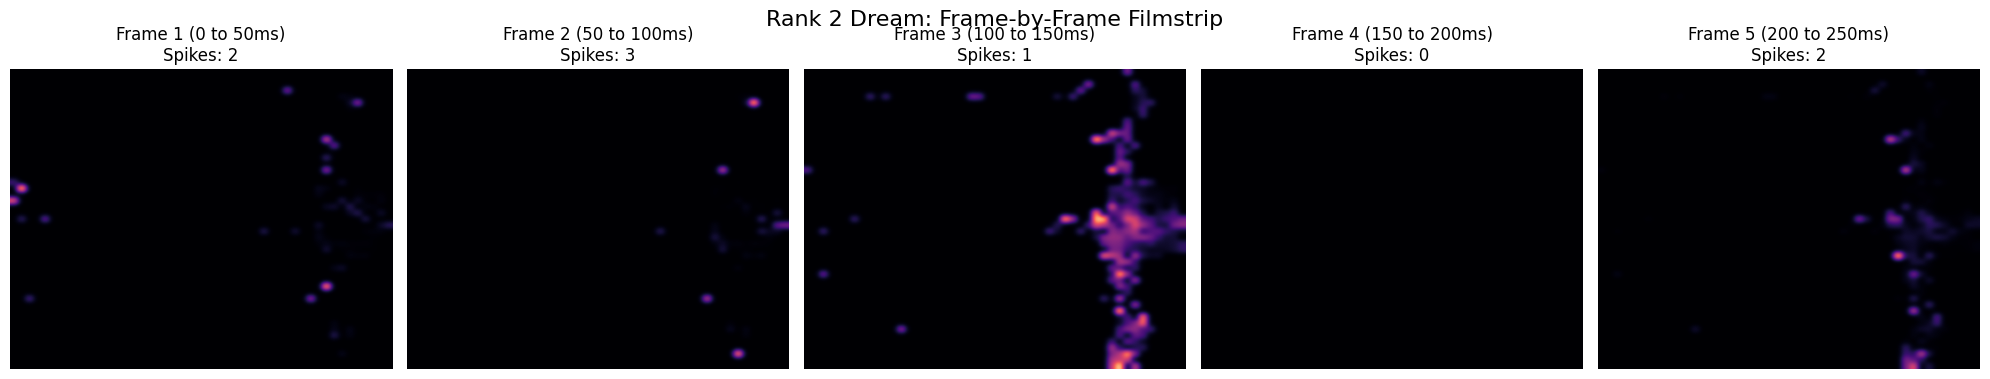

In [ ]:
# frame by frame for rank 2, see spike distribution per time interval, how connect the dots was generated

import numpy as np
import matplotlib.pyplot as plt

# 1. Isolate the exact start and end time of Rank 2
rank2_bin_idx = top_5_indices[3]
start_tick = bin_edges[rank2_bin_idx]

# 2. Chop the 250ms window into 5 distinct 50ms frames
window_ticks = 0.050 * 20000 # 50ms in ticks
time_steps = np.arange(start_tick, start_tick + (5 * window_ticks), window_ticks)

fig, axes = plt.subplots(1, len(time_steps), figsize=(20, 4))

print("--- RANK 2 FILMSTRIP ---")

for i, t in enumerate(time_steps):
    # Count spikes for this specific 50ms frame
    pop_vector = []
    for idx in place_cell_indices:
        neuron_spikes = neuron_spike_lists[idx]
        spikes = np.sum((neuron_spikes >= t) & (neuron_spikes < t + window_ticks))
        pop_vector.append(spikes)

    posterior = np.ones((49, 49))
    tau = 0.050
    total_spikes = np.sum(pop_vector)

    # Only run the heavy math if there are actual spikes
    if total_spikes > 0:
        for j in range(len(place_cell_indices)):
            n_j = pop_vector[j]
            f_j = filtered_tuning_curves[j]
            posterior *= (np.power(f_j + 1e-10, n_j) * np.exp(-tau * f_j))

        if np.sum(posterior) > 0:
            posterior /= np.sum(posterior)

    # Plot the frame
    axes[i].imshow(posterior.T, origin='lower', cmap='magma', interpolation='gaussian',
                   extent=[x_edges[0], x_edges[-1], y_edges[0], y_edges[-1]])

    # Calculate time offset in milliseconds for the title
    time_offset_ms = i * 50
    axes[i].set_title(f"Frame {i+1} ({time_offset_ms} to {time_offset_ms+50}ms)\nSpikes: {total_spikes}")
    axes[i].axis('off')
    axes[i].invert_yaxis()

plt.suptitle("Rank 2 Dream: Frame-by-Frame Filmstrip", fontsize=16)
plt.tight_layout()
plt.show()

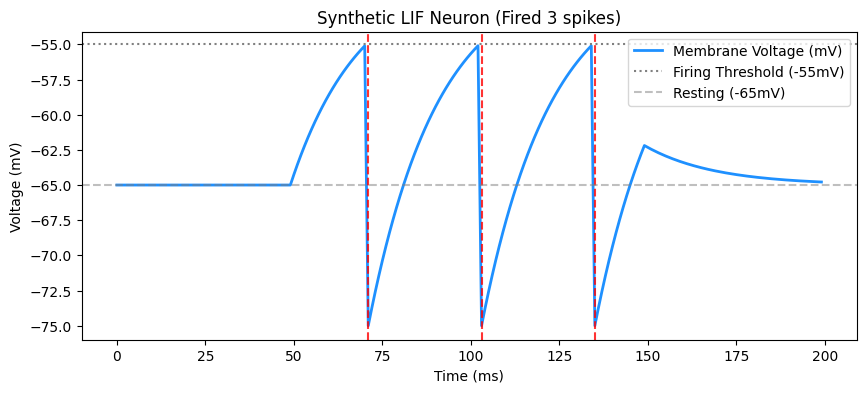

In [ ]:
#sample leaky integrate and fire spiking neural network,
#using learned parameters

import numpy as np
import matplotlib.pyplot as plt

# 1. BIOLOGICAL PHYSICS PARAMETERS
tau_m = 20.0      # Membrane time constant (How fast it leaks in ms)
V_rest = -65.0    # Resting voltage (mV)
V_reset = -75.0   # Voltage after it fires and drains (mV)
V_thresh = -55.0  # The tripwire: It must hit this to fire (mV)
R_m = 10.0        # Membrane resistance

# 2. SIMULATION SETUP
dt = 1.0          # 1 millisecond per step
T = 200           # 200 ms total simulation
time = np.arange(0, T, dt)

# 3. THE EXPERIMENT: Injecting electrical current
# We will shock the neuron with 1.5 nA of electricity from 50ms to 150ms
I_ext = np.zeros(len(time))
I_ext[50:150] = 1.5

# 4. THE PHYSICS ENGINE
V = np.zeros(len(time))
V[0] = V_rest
spikes = []

for i in range(1, len(time)):
    # Calculate the Leak and the Integration
    dV = (-(V[i-1] - V_rest) + R_m * I_ext[i]) / tau_m * dt
    V[i] = V[i-1] + dV

    # Check if it hits the threshold to fire!
    if V[i] >= V_thresh:
        V[i] = V_reset         # Drain the battery
        spikes.append(time[i]) # Record the spike timestamp

# 5. PLOT THE RESULTS
plt.figure(figsize=(10, 4))
plt.plot(time, V, label="Membrane Voltage (mV)", color='dodgerblue', linewidth=2)

# Draw red lines where it fired a spike
for t in spikes:
    plt.axvline(t, color='red', linestyle='--', alpha=0.8)

plt.axhline(V_thresh, color='gray', linestyle=':', label='Firing Threshold (-55mV)')
plt.axhline(V_rest, color='gray', linestyle='--', alpha=0.5, label='Resting (-65mV)')

plt.title(f"Synthetic LIF Neuron (Fired {len(spikes)} spikes)")
plt.xlabel("Time (ms)")
plt.ylabel("Voltage (mV)")
plt.legend(loc="upper right")
plt.show()

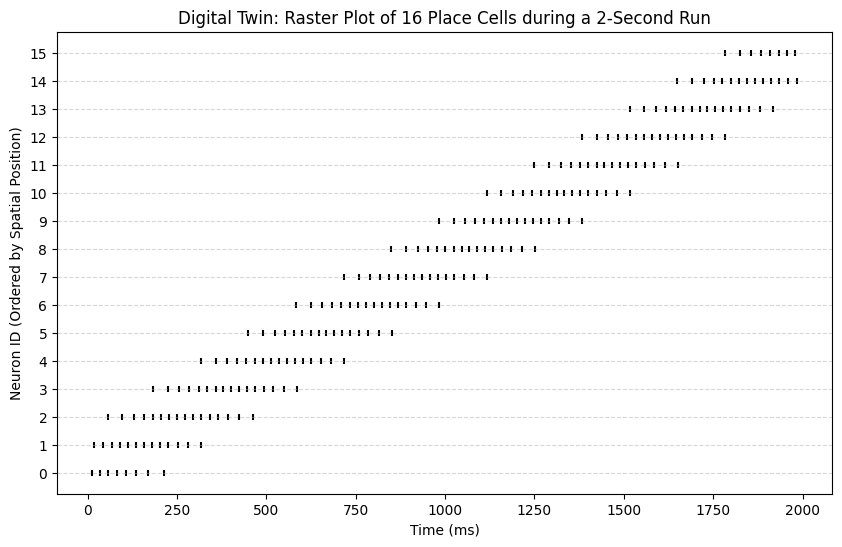

In [ ]:
#spiking of each of 16 place cells based on time, awake

import numpy as np
import matplotlib.pyplot as plt

# 1. BIOLOGICAL PHYSICS (Same as before)
tau_m = 20.0
V_rest = -65.0
V_reset = -75.0
V_thresh = -55.0
R_m = 10.0

# 2. DIGITAL TWIN SETUP
N_cells = 16
track_length = 100.0  # 100 cm track
sim_time_ms = 2000    # 2 seconds total simulation
dt = 1.0
time = np.arange(0, sim_time_ms, dt)

# Assign evenly spaced "favorite spots" (mu) for all 16 cells
favorite_spots = np.linspace(0, track_length, N_cells)
field_width = 10.0  # sigma (how wide the receptive field is)
I_max = 2.0         # Maximum current injected when at the exact center

# 3. SIMULATE THE RAT RUNNING
# The rat runs from 0cm to 100cm at a constant speed over the 2000ms
rat_position = np.linspace(0, track_length, len(time))

# 4. THE 16-CELL PHYSICS ENGINE
# Instead of 1 battery, we now track 16 batteries simultaneously!
V = np.ones(N_cells) * V_rest
spike_times = []
spike_neurons = []

for i, t in enumerate(time):
    current_pos = rat_position[i]

    # Calculate how much current EACH of the 16 neurons receives based on the rat's position
    I_ext = I_max * np.exp(-((current_pos - favorite_spots)**2) / (2 * field_width**2))

    # Update voltage for all 16 neurons at once using vector math
    dV = (-(V - V_rest) + R_m * I_ext) / tau_m * dt
    V += dV

    # Check which neurons hit the threshold
    firing_neurons = np.where(V >= V_thresh)[0]

    for neuron_id in firing_neurons:
        V[neuron_id] = V_reset          # Drain the battery of the firing neuron
        spike_times.append(t)           # Record the timestamp
        spike_neurons.append(neuron_id) # Record WHO fired

# 5. PLOT THE DIGITAL RASTER PLOT
plt.figure(figsize=(10, 6))

# Plot the spike times as dots (a raster plot)
plt.scatter(spike_times, spike_neurons, color='black', s=15, marker='|')

plt.title("Digital Twin: Raster Plot of 16 Place Cells during a 2-Second Run")
plt.xlabel("Time (ms)")
plt.ylabel("Neuron ID (Ordered by Spatial Position)")
plt.yticks(np.arange(0, 16))
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

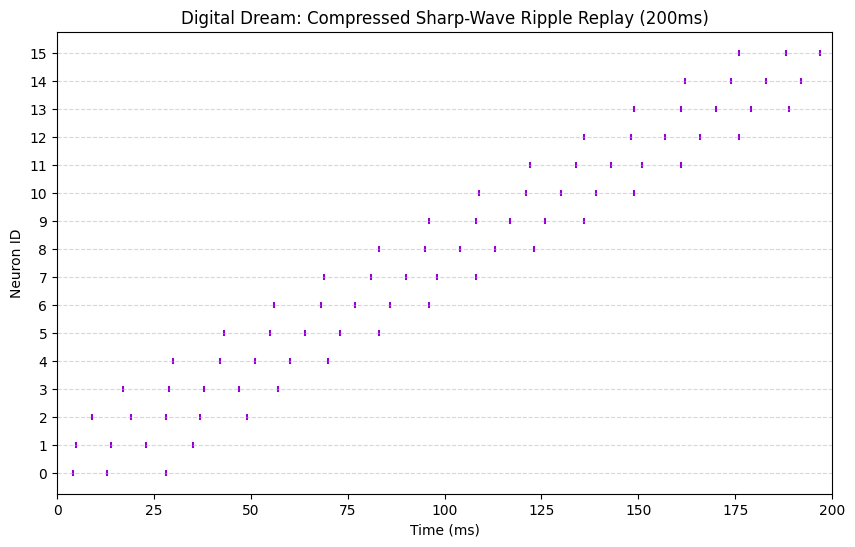

In [ ]:
#spiking of each of 16 place cells based on time, sharp wave ripples

import numpy as np
import matplotlib.pyplot as plt

# 1. BIOLOGICAL PHYSICS
tau_m = 20.0
V_rest = -65.0
V_reset = -75.0
V_thresh = -55.0
R_m = 10.0

# 2. DIGITAL TWIN SETUP (THE DREAM)
N_cells = 16
track_length = 100.0
sim_time_ms = 200     # THE DREAM: Compressed to 200 milliseconds!
dt = 1.0
time = np.arange(0, sim_time_ms, dt)

favorite_spots = np.linspace(0, track_length, N_cells)
field_width = 10.0
I_max = 5.0           # Increased current to simulate the powerful Sharp-Wave Ripple

# 3. SIMULATE THE COMPRESSED REPLAY
# The mental rat runs 0 to 100cm in just 200ms
rat_position = np.linspace(0, track_length, len(time))

V = np.ones(N_cells) * V_rest
spike_times = []
spike_neurons = []

for i, t in enumerate(time):
    current_pos = rat_position[i]
    I_ext = I_max * np.exp(-((current_pos - favorite_spots)**2) / (2 * field_width**2))

    dV = (-(V - V_rest) + R_m * I_ext) / tau_m * dt
    V += dV

    firing_neurons = np.where(V >= V_thresh)[0]

    for neuron_id in firing_neurons:
        V[neuron_id] = V_reset
        spike_times.append(t)
        spike_neurons.append(neuron_id)

# 5. PLOT THE DIGITAL DREAM RASTER
plt.figure(figsize=(10, 6))
plt.scatter(spike_times, spike_neurons, color='darkviolet', s=15, marker='|')

plt.title("Digital Dream: Compressed Sharp-Wave Ripple Replay (200ms)")
plt.xlabel("Time (ms)")
plt.ylabel("Neuron ID")
plt.yticks(np.arange(0, 16))
plt.xlim(0, 200)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

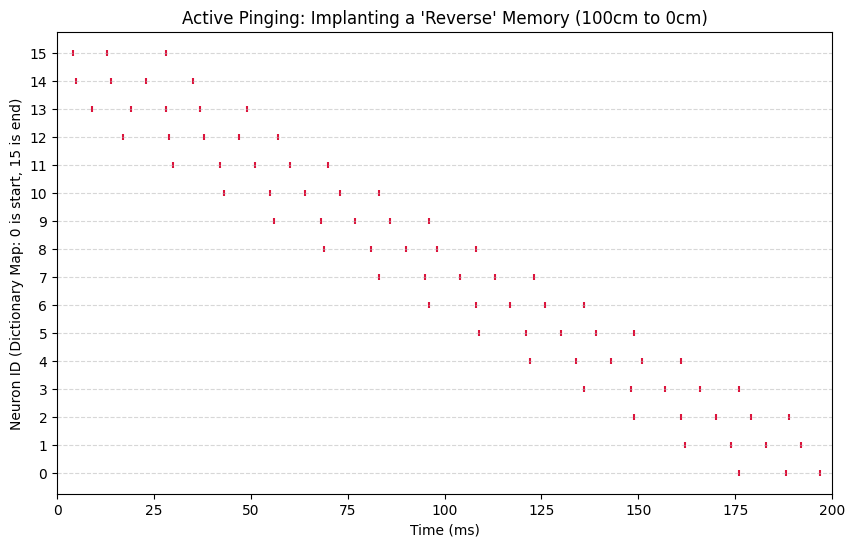

In [ ]:
#implantation of fake memory, reverse run

import numpy as np
import matplotlib.pyplot as plt

# 1. BIOLOGICAL PHYSICS (Standard LIF)
tau_m = 20.0; V_rest = -65.0; V_reset = -75.0; V_thresh = -55.0; R_m = 10.0

# 2. DIGITAL TWIN SETUP
N_cells = 16
track_length = 100.0
sim_time_ms = 200     # 200ms Active Ping Window
dt = 1.0
time = np.arange(0, sim_time_ms, dt)

# THE DICTIONARY (Learned from passive listening)
# Cell 0 is 0cm, Cell 15 is 100cm
favorite_spots = np.linspace(0, track_length, N_cells)
field_width = 10.0
I_max = 5.0

# 3. MEMORY INCEPTION (The Hack)
# We artificially create a "Reverse" path starting at 100cm and ending at 0cm.
fake_trajectory = np.linspace(track_length, 0, len(time))

V = np.ones(N_cells) * V_rest
spike_times = []
spike_neurons = []

for i, t in enumerate(time):
    current_pos = fake_trajectory[i]

    # We actively ping the network based on our fake backward trajectory
    I_ext = I_max * np.exp(-((current_pos - favorite_spots)**2) / (2 * field_width**2))

    dV = (-(V - V_rest) + R_m * I_ext) / tau_m * dt
    V += dV

    firing_neurons = np.where(V >= V_thresh)[0]

    for neuron_id in firing_neurons:
        V[neuron_id] = V_reset
        spike_times.append(t)
        spike_neurons.append(neuron_id)

# 5. PLOT THE IMPLANTED MEMORY
plt.figure(figsize=(10, 6))
plt.scatter(spike_times, spike_neurons, color='crimson', s=15, marker='|')

plt.title("Active Pinging: Implanting a 'Reverse' Memory (100cm to 0cm)")
plt.xlabel("Time (ms)")
plt.ylabel("Neuron ID (Dictionary Map: 0 is start, 15 is end)")
plt.yticks(np.arange(0, 16))
plt.xlim(0, 200)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

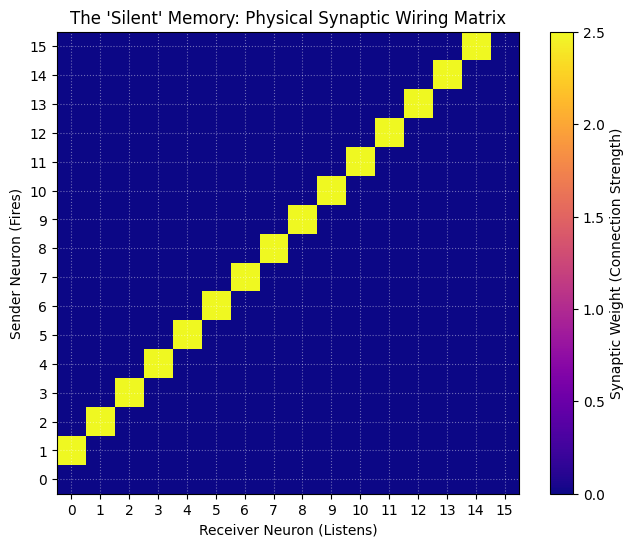

In [ ]:
# assign synaptic weights, so that each neuron triggers the next.
# structural memory without electricity

import numpy as np
import matplotlib.pyplot as plt

# 1. SETUP THE BRAIN'S ARCHITECTURE
N_cells = 16

# Create a 16x16 grid of zeros (a totally blank brain with no memories)
W = np.zeros((N_cells, N_cells))

# 2. EMBED THE SILENT MEMORY (The Ground Truth)
# We tie the "strings" to force a reverse sequence: Cell i triggers Cell i-1
synaptic_strength = 2.5  # How much electricity leaks from the sender to the receiver

for i in range(1, N_cells):
    sender = i
    receiver = i - 1

    # We physically alter the weight matrix to create the memory chain
    W[sender, receiver] = synaptic_strength

# 3. VISUALIZE THE SILENT MEMORY
plt.figure(figsize=(8, 6))

# Plot the matrix as a heatmap
plt.imshow(W, cmap='plasma', origin='lower')
plt.colorbar(label="Synaptic Weight (Connection Strength)")

plt.title("The 'Silent' Memory: Physical Synaptic Wiring Matrix")
plt.xlabel("Receiver Neuron (Listens)")
plt.ylabel("Sender Neuron (Fires)")
plt.xticks(np.arange(N_cells))
plt.yticks(np.arange(N_cells))
plt.grid(color='white', linestyle=':', alpha=0.4)

plt.show()

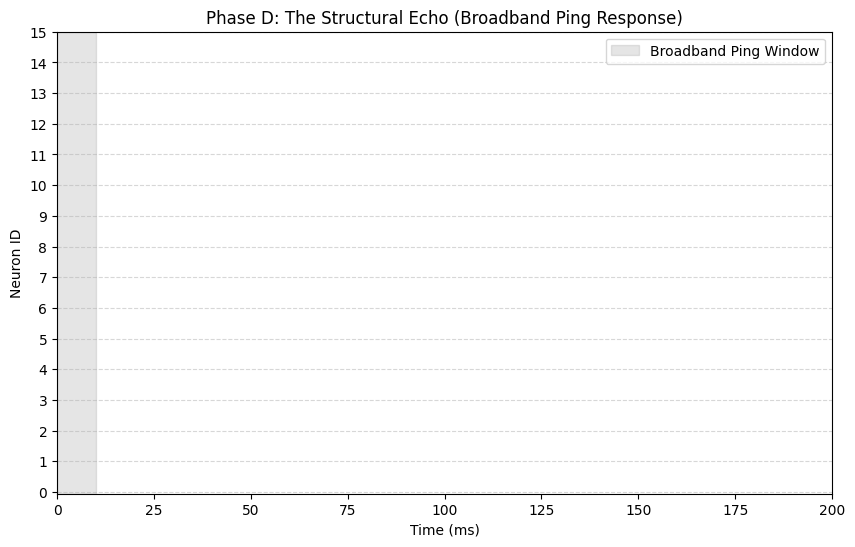

In [ ]:
# random ping strength

import numpy as np
import matplotlib.pyplot as plt

# 1. BIOLOGICAL PHYSICS (Standard LIF + Synaptic Decay)
tau_m = 20.0; V_rest = -65.0; V_reset = -75.0; V_thresh = -55.0; R_m = 10.0
tau_syn = 5.0      # Synaptic time constant (How long the chemical echo lasts in ms)
dt = 1.0

# 2. SIMULATION SETUP
N_cells = 16
sim_time_ms = 200  # 200ms window
time = np.arange(0, sim_time_ms, dt)

# 3. INITIALIZE THE DIGITAL TWIN STATE
V = np.ones(N_cells) * V_rest
I_syn = np.zeros(N_cells) # Tracks the active chemical current inside the synapses

spike_times = []
spike_neurons = []

# 4. RUN THE ACTIVE RETRIEVAL ENGINE
for i, t in enumerate(time):

    # STEP A: Inject the Broadband Ping (Only for the first 10ms)
    if t < 10.0:
        # Random chaotic static blasted into all 16 cells simultaneously
        I_ping = np.random.normal(loc=2.2, scale=0.5, size=N_cells)
    else:
        # Complete environmental silence after 10ms
        I_ping = np.zeros(N_cells)

    # STEP B: Decay the synaptic current from the previous time step
    # The chemicals naturally wash away
    I_syn += (-I_syn / tau_syn) * dt

    # STEP C: Total current is the Ping + any Synaptic echoes traveling through the matrix
    I_total = I_ping + I_syn

    # STEP D: Update the LIF voltage equations
    dV = (-(V - V_rest) + R_m * I_total) / tau_m * dt
    V += dV

    # STEP E: Check for Spikes
    firing_neurons = np.where(V >= V_thresh)[0]

    for neuron_id in firing_neurons:
        V[neuron_id] = V_reset          # Reset the fired cell
        spike_times.append(t)           # Record time
        spike_neurons.append(neuron_id) # Record WHO fired

        # THE ECHO MECHANISM:
        # This cell fires, so it instantly dumps current into its receivers
        # based on our 16x16 Synaptic Weight Matrix (W) from the previous step!
        I_syn += W[neuron_id, :]

# 5. PLOT THE STRUCTURAL ECHO
plt.figure(figsize=(10, 6))
plt.scatter(spike_times, spike_neurons, color='teal', s=20, marker='|')

# Highlight the broadband ping window
plt.axvspan(0, 10, color='gray', alpha=0.2, label='Broadband Ping Window')

plt.title("Phase D: The Structural Echo (Broadband Ping Response)")
plt.xlabel("Time (ms)")
plt.ylabel("Neuron ID")
plt.yticks(np.arange(0, 16))
plt.xlim(0, 200)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

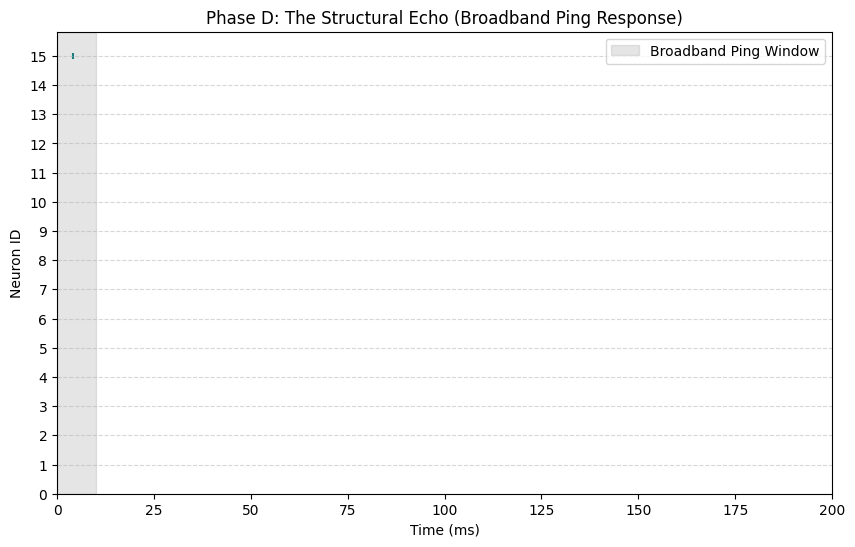

In [ ]:
# ping triggers neuron 15, but signal attenuation stopped further

import numpy as np
import matplotlib.pyplot as plt

# 1. BIOLOGICAL PHYSICS (Standard LIF + Synaptic Decay)
tau_m = 20.0; V_rest = -65.0; V_reset = -75.0; V_thresh = -55.0; R_m = 10.0
tau_syn = 5.0      # Synaptic time constant (How long the chemical echo lasts in ms)
dt = 1.0

# 2. SIMULATION SETUP
N_cells = 16
sim_time_ms = 200  # 200ms window
time = np.arange(0, sim_time_ms, dt)

# 3. INITIALIZE THE DIGITAL TWIN STATE
V = np.ones(N_cells) * V_rest
I_syn = np.zeros(N_cells) # Tracks the active chemical current inside the synapses

spike_times = []
spike_neurons = []

# 4. RUN THE ACTIVE RETRIEVAL ENGINE
for i, t in enumerate(time):

# STEP A: Inject a Targeted Ping (Only into Neuron 15, for 10ms)
    if t < 10.0:
        I_ping = np.zeros(N_cells)
        I_ping[15] = 5.0  # A sharp, guaranteed spark only on the first domino
    else:
        I_ping = np.zeros(N_cells)

    # STEP B: Decay the synaptic current from the previous time step
    # The chemicals naturally wash away
    I_syn += (-I_syn / tau_syn) * dt

    # STEP C: Total current is the Ping + any Synaptic echoes traveling through the matrix
    I_total = I_ping + I_syn

    # STEP D: Update the LIF voltage equations
    dV = (-(V - V_rest) + R_m * I_total) / tau_m * dt
    V += dV

    # STEP E: Check for Spikes
    firing_neurons = np.where(V >= V_thresh)[0]

    for neuron_id in firing_neurons:
        V[neuron_id] = V_reset          # Reset the fired cell
        spike_times.append(t)           # Record time
        spike_neurons.append(neuron_id) # Record WHO fired

        # THE ECHO MECHANISM:
        # This cell fires, so it instantly dumps current into its receivers
        # based on our 16x16 Synaptic Weight Matrix (W) from the previous step!
        I_syn += W[neuron_id, :]

# 5. PLOT THE STRUCTURAL ECHO
plt.figure(figsize=(10, 6))
plt.scatter(spike_times, spike_neurons, color='teal', s=20, marker='|')

# Highlight the broadband ping window
plt.axvspan(0, 10, color='gray', alpha=0.2, label='Broadband Ping Window')

plt.title("Phase D: The Structural Echo (Broadband Ping Response)")
plt.xlabel("Time (ms)")
plt.ylabel("Neuron ID")
plt.yticks(np.arange(0, 16))
plt.xlim(0, 200)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

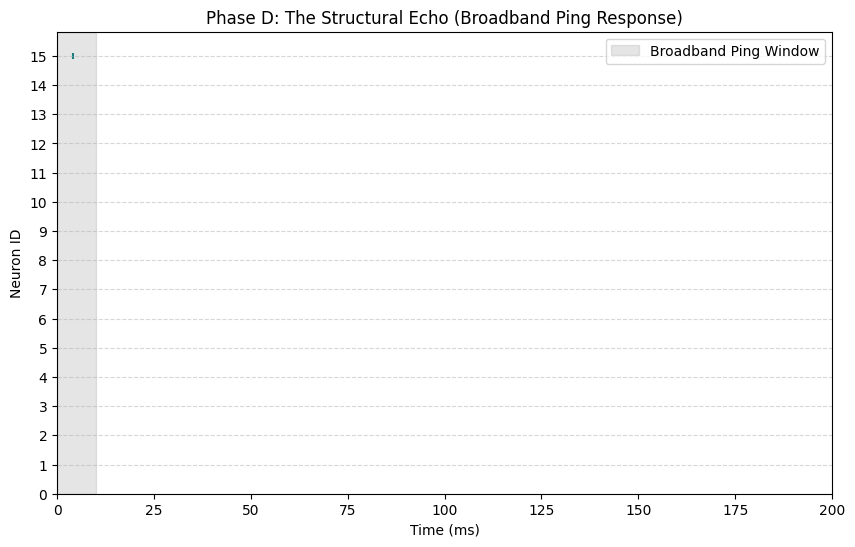

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. BIOLOGICAL PHYSICS (Standard LIF + Synaptic Decay)
tau_m = 20.0; V_rest = -65.0; V_reset = -75.0; V_thresh = -55.0; R_m = 10.0
tau_syn = 5.0      # Synaptic time constant (How long the chemical echo lasts in ms)
dt = 1.0

# 2. SIMULATION SETUP
N_cells = 16
sim_time_ms = 200  # 200ms window
time = np.arange(0, sim_time_ms, dt)

# 3. INITIALIZE THE DIGITAL TWIN STATE
V = np.ones(N_cells) * V_rest
I_syn = np.zeros(N_cells) # Tracks the active chemical current inside the synapses

spike_times = []
spike_neurons = []

# 3.5 BOOST THE SYNAPTIC WEIGHTS
# We multiply our entire hidden matrix by 3 to ensure the dominoes fall!
W = W * 3.0

# 4. RUN THE ACTIVE RETRIEVAL ENGINE
for i, t in enumerate(time):

# STEP A: Inject a Targeted Ping (Only into Neuron 15, for 10ms)
    if t < 10.0:
        I_ping = np.zeros(N_cells)
        I_ping[15] = 5.0  # A sharp, guaranteed spark only on the first domino
    else:
        I_ping = np.zeros(N_cells)

    # STEP B: Decay the synaptic current from the previous time step
    # The chemicals naturally wash away
    I_syn += (-I_syn / tau_syn) * dt

    # STEP C: Total current is the Ping + any Synaptic echoes traveling through the matrix
    I_total = I_ping + I_syn

    # STEP D: Update the LIF voltage equations
    dV = (-(V - V_rest) + R_m * I_total) / tau_m * dt
    V += dV

    # STEP E: Check for Spikes
    firing_neurons = np.where(V >= V_thresh)[0]

    for neuron_id in firing_neurons:
        V[neuron_id] = V_reset          # Reset the fired cell
        spike_times.append(t)           # Record time
        spike_neurons.append(neuron_id) # Record WHO fired

        # THE ECHO MECHANISM:
        # This cell fires, so it instantly dumps current into its receivers
        # based on our 16x16 Synaptic Weight Matrix (W) from the previous step!
        I_syn += W[neuron_id, :]

# 5. PLOT THE STRUCTURAL ECHO
plt.figure(figsize=(10, 6))
plt.scatter(spike_times, spike_neurons, color='teal', s=20, marker='|')

# Highlight the broadband ping window
plt.axvspan(0, 10, color='gray', alpha=0.2, label='Broadband Ping Window')

plt.title("Phase D: The Structural Echo (Broadband Ping Response)")
plt.xlabel("Time (ms)")
plt.ylabel("Neuron ID")
plt.yticks(np.arange(0, 16))
plt.xlim(0, 200)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

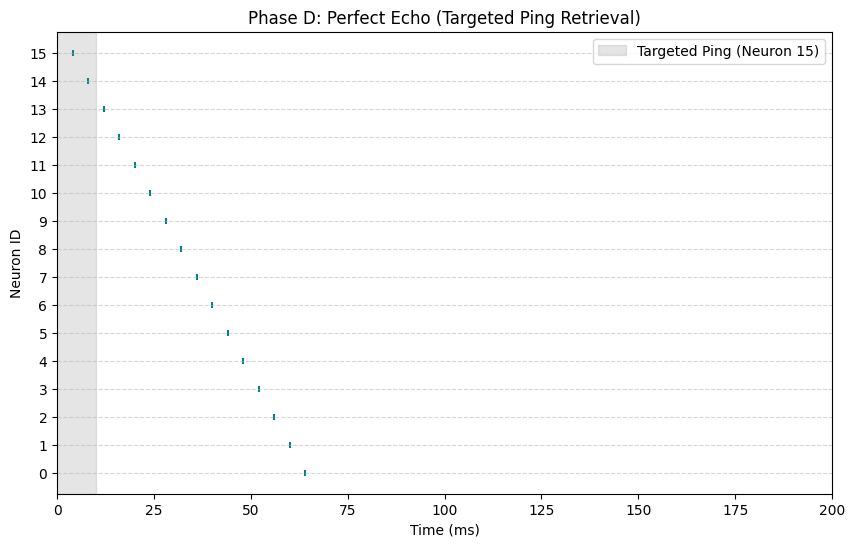

In [ ]:
# targeted weight of 10 for stronger memory

import numpy as np
import matplotlib.pyplot as plt

# 1. BIOLOGICAL PHYSICS
tau_m = 20.0; V_rest = -65.0; V_reset = -75.0; V_thresh = -55.0; R_m = 10.0
tau_syn = 5.0
dt = 1.0

# 2. BUILD A FRESH BRAIN EVERY TIME YOU PRESS PLAY
N_cells = 16
W = np.zeros((N_cells, N_cells))
perfect_weight = 10.0       # The true "Goldilocks" weight

# Embed the silent memory (Reverse chain: 15->14->13...)
for i in range(1, N_cells):
    W[i, i - 1] = perfect_weight

# 3. INITIALIZE SIMULATION
sim_time_ms = 200
time = np.arange(0, sim_time_ms, dt)

V = np.ones(N_cells) * V_rest
I_syn = np.zeros(N_cells)

spike_times = []
spike_neurons = []

# 4. RUN THE ACTIVE RETRIEVAL ENGINE
for i, t in enumerate(time):

    # STEP A: Sniper Ping on Neuron 15 (Only first 10ms)
    if t < 10.0:
        I_ping = np.zeros(N_cells)
        I_ping[15] = 5.0
    else:
        I_ping = np.zeros(N_cells)

    # STEP B: Decay
    I_syn += (-I_syn / tau_syn) * dt

    # STEP C: Total current
    I_total = I_ping + I_syn

    # STEP D: Update LIF
    dV = (-(V - V_rest) + R_m * I_total) / tau_m * dt
    V += dV

    # STEP E: Check for Spikes
    firing_neurons = np.where(V >= V_thresh)[0]

    for neuron_id in firing_neurons:
        V[neuron_id] = V_reset
        spike_times.append(t)
        spike_neurons.append(neuron_id)

        # Echo mechanism
        I_syn += W[neuron_id, :]

# 5. PLOT THE PERFECT ECHO
plt.figure(figsize=(10, 6))
plt.scatter(spike_times, spike_neurons, color='teal', s=20, marker='|')

plt.axvspan(0, 10, color='gray', alpha=0.2, label='Targeted Ping (Neuron 15)')

plt.title("Phase D: Perfect Echo (Targeted Ping Retrieval)")
plt.xlabel("Time (ms)")
plt.ylabel("Neuron ID")
plt.yticks(np.arange(0, 16))
plt.xlim(0, 200)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

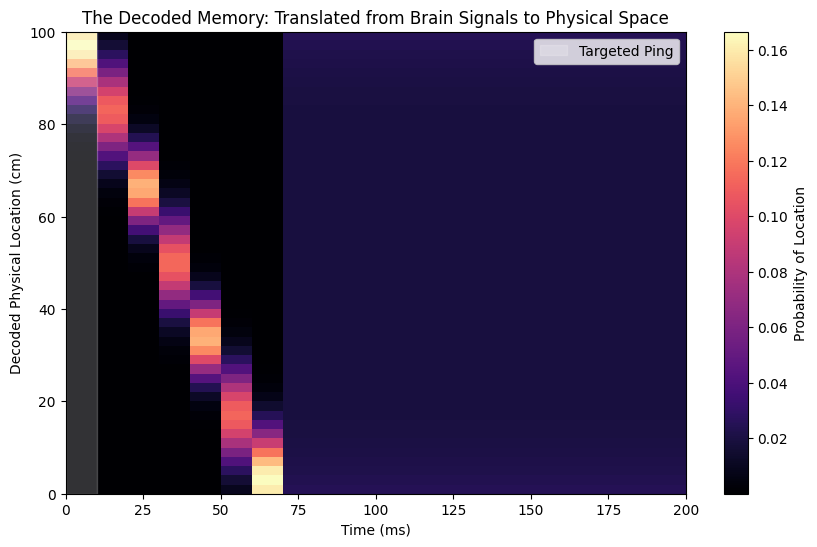

In [ ]:
#translate neuron IDs into physical space meaning

import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. PHASE D: GENERATE THE ECHO (The SNN)
# ==========================================
N_cells = 16
tau_m = 20.0; V_rest = -65.0; V_reset = -75.0; V_thresh = -55.0; R_m = 10.0
tau_syn = 5.0
dt = 1.0
sim_time_ms = 200
time = np.arange(0, sim_time_ms, dt)

# Build the Matrix (10.0 weight for a perfect reverse chain)
W = np.zeros((N_cells, N_cells))
for i in range(1, N_cells):
    W[i, i - 1] = 10.0

V = np.ones(N_cells) * V_rest
I_syn = np.zeros(N_cells)
spike_times = []
spike_neurons = []

# Run the SNN
for i, t in enumerate(time):
    if t < 10.0:
        I_ping = np.zeros(N_cells)
        I_ping[15] = 5.0  # Targeted Ping
    else:
        I_ping = np.zeros(N_cells)

    I_syn += (-I_syn / tau_syn) * dt
    I_total = I_ping + I_syn
    dV = (-(V - V_rest) + R_m * I_total) / tau_m * dt
    V += dV

    firing_neurons = np.where(V >= V_thresh)[0]
    for neuron_id in firing_neurons:
        V[neuron_id] = V_reset
        spike_times.append(t)
        spike_neurons.append(neuron_id)
        I_syn += W[neuron_id, :]

# ==========================================
# 2. PHASE B (Part 1): BUILD THE DICTIONARY
# ==========================================
track_length = 100.0
N_space_bins = 50  # We divide the 100cm track into 50 chunks
positions = np.linspace(0, track_length, N_space_bins)
favorite_spots = np.linspace(0, track_length, N_cells)
field_width = 10.0

# Create Tuning Curves (Expected firing rate for each cell at each position)
tuning_curves = np.zeros((N_cells, N_space_bins))
for i in range(N_cells):
    # Gaussian bell curve for each cell's favorite spot
    tuning_curves[i, :] = 20.0 * np.exp(-((positions - favorite_spots[i])**2) / (2 * field_width**2)) + 0.1

# ==========================================
# 3. PHASE B (Part 2): THE BAYESIAN DECODER
# ==========================================
time_bin_size = 10.0
time_bins = np.arange(0, sim_time_ms + time_bin_size, time_bin_size)
N_time_bins = len(time_bins) - 1

# Step A: Count how many times each neuron fired in each 10ms bin
spike_counts = np.zeros((N_cells, N_time_bins))
for i in range(len(spike_times)):
    t = spike_times[i]
    neuron = spike_neurons[i]
    bin_idx = int(t / time_bin_size)
    if bin_idx < N_time_bins:
        spike_counts[neuron, bin_idx] += 1

# Step B: Decode! Use Bayes Theorem to calculate probability of location
posterior = np.zeros((N_space_bins, N_time_bins))
tau = time_bin_size / 1000.0 # Convert ms to seconds

for t_idx in range(N_time_bins):
    n = spike_counts[:, t_idx] # The spikes in this specific bin

    log_prob = np.zeros(N_space_bins)
    for x_idx in range(N_space_bins):
        lam = tuning_curves[:, x_idx]
        # The Poisson Naive Bayes Formula
        log_prob[x_idx] = np.sum(n * np.log(lam * tau) - (lam * tau))

    # Convert math back to a clean percentage (0 to 1.0)
    log_prob -= np.max(log_prob)
    prob = np.exp(log_prob)
    if np.sum(prob) > 0:
        posterior[:, t_idx] = prob / np.sum(prob)

# ==========================================
# 4. PLOT THE FINAL TRANSLATION
# ==========================================
plt.figure(figsize=(10, 6))

# Plot the probability heatmap
plt.imshow(posterior, origin='lower', aspect='auto', cmap='magma',
           extent=[0, sim_time_ms, 0, track_length])

plt.colorbar(label="Probability of Location")
plt.title("The Decoded Memory: Translated from Brain Signals to Physical Space")
plt.xlabel("Time (ms)")
plt.ylabel("Decoded Physical Location (cm)")

# Overlay the actual ping time for reference
plt.axvspan(0, 10, color='white', alpha=0.2, label='Targeted Ping')
plt.legend()

plt.show()